In [2]:
import numpy as np
from scipy.optimize import minimize
from netCDF4 import Dataset 
import matplotlib.pyplot as plt

In [3]:
zdim = 501

height = np.zeros(97)
plev = np.zeros(97)
h1d = np.zeros(zdim)
dz = 500.
hh = 7000.
dz1d = 100000/(zdim-1)
for k in range(97):
    height[k] = k*dz
    plev[k] = 1000*np.exp(-height[k]/hh)
for k in range(zdim):
    h1d[k] = dz1d*k+10000.

print(height[96])
print(h1d[0])

48000.0
10000.0


In [4]:
filename1 = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/ana60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz = ncin1.variables['epz'] 
epz = (np.array(epz))
fawa = ncin1.variables['fawa'] 
fawa = (np.array(fawa))
ubar = ncin1.variables['ubar'] 
ubar = (np.array(ubar))
uref = ncin1.variables['uref'] 
uref = (np.array(uref))


filename1 = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/tran60n.nc'
ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
epz_tran = ncin1.variables['epz'] 
epz_tran = (np.array(epz_tran))
fawa_tran = ncin1.variables['fawa'] 
fawa_tran = (np.array(fawa_tran))
ubar_tran = ncin1.variables['ubar'] 
ubar_tran = (np.array(ubar_tran))
uref_tran = ncin1.variables['uref'] 
uref_tran = (np.array(uref_tran))
print(epz.shape)

file = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/sea60n.nc'
ncin1 = Dataset(file, 'r', format='NETCDF4') 
fawa_sea = ncin1.variables['fawa'] 
fawa_sea = (np.array(fawa_sea))
ubar_sea = ncin1.variables['ubar'] 
ubar_sea = (np.array(ubar_sea))
uref_sea = ncin1.variables['uref']
uref_sea = (np.array(uref_sea))
epz_sea = ncin1.variables['epz'] 
epz_sea = (np.array(epz_sea))
print(fawa_sea.shape)

fawa_sea_n = np.zeros((97, 124, 12, 43))
ubar_sea_n = np.zeros((97, 124, 12, 43))
uref_sea_n = np.zeros((97, 124, 12, 43))
epz_sea_n = np.zeros((97, 124, 12, 43))

for i in range(43):
    fawa_sea_n[:,:,:,i] = fawa_sea[:,:,:]
    ubar_sea_n[:,:,:,i] = ubar_sea[:,:,:]
    uref_sea_n[:,:,:,i] = uref_sea[:,:,:]
    epz_sea_n[:,:,:,i] = epz_sea[:,:,:]


def Oct_to_May(vv):

    i=0
    vbar = np.zeros((97,42,992))
    days = np.zeros(8)
    dddd = np.zeros((42,992))
    date = dddd.tolist()

    month = [9,10,11,0,1,2,3,4]

    time = ['00','06','12','18']
    months = ['10','11','12','01','02','03','04','05']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<8):
                j=0
                while(j<124):
                    if m<3:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def Nov_to_Mar(vv):

    i=0
    vbar = np.zeros((97,42,604))
    days = np.zeros(5)
    dddd = np.zeros((42,604))
    date = dddd.tolist()

    month = [10,11,0,1,2]

    time = ['00','06','12','18']
    months = ['11','12','01','02','03']
    dates = ['01','02','03','04','05','06','07','08','09','10',   \
             '11','12','13','14','15','16','17','18','19',        \
            '20','21','22','23','24','25','26','27','28','29','30','31']

    for z in range(97):
        i=0
        while(i<42):
            m=0
            k=0
            while(m<5):
                j=0
                while(j<124):
                    if m<2:
                        if vv[z,j,month[m],i]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i]
                            date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    else:
                        if vv[z,j,month[m],i+1]!=0:
                            vbar[z,i,k] = vv[z,j,month[m],i+1]
                            date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                            k=k+1
                    j=j+1
                days[m]=k
                m=m+1
            vbar[vbar==0]=np.nan

            i=i+1

    return vbar

def sixty_to_sixty(onset_id,dmax,vbar):

    yy=0

    vb = np.zeros((97,22,121*4))

    i=0
    while(i<42):
        for n in range(onset_id.shape[0]):
            if onset_id[n]!=0:
                if int((onset_id[n]+(dmax-1))/(dmax-1))-1==i:
                    kk = onset_id[n]-(dmax-1)*i
                    #print(n,kk)
                    for k in range(int(kk-60*4),int(kk+61*4)):
                        z=0
                        while(z<97):
                            x = int(abs(k-kk+60*4))
                            #print(x)
                            vb[z,yy,x] = vbar[z,i,k]  #################################
                            z=z+1
                    yy = yy+1
        i=i+1
        
    return vb




(97, 124, 12, 43)
(97, 124, 12)


In [5]:

uref_eachyr = Nov_to_Mar(uref)
ubar_eachyr = Nov_to_Mar(ubar)
fawa_eachyr = Nov_to_Mar(fawa)
epz_eachyr = Nov_to_Mar(epz)

print('done')

uref_sea_novmar = np.mean(Nov_to_Mar(uref_sea_n),axis=1)
ubar_sea_novmar = np.mean(Nov_to_Mar(ubar_sea_n),axis=1)
fawa_sea_novmar = np.mean(Nov_to_Mar(fawa_sea_n),axis=1)
epz_sea_novmar = np.mean(Nov_to_Mar(epz_sea_n),axis=1)

print('done')

uref_eachyr_oct_to_may = Oct_to_May(uref)
ubar_eachyr_oct_to_may = Oct_to_May(ubar)
fawa_eachyr_oct_to_may = Oct_to_May(fawa)
epz_eachyr_oct_to_may = Oct_to_May(epz)

ubar_sea_octmay = np.mean(Oct_to_May(ubar_sea_n),axis=1)
uref_sea_octmay = np.mean(Oct_to_May(uref_sea_n),axis=1)
epz_sea_octmay = np.mean(Oct_to_May(epz_sea_n),axis=1)

print('done')


done
done
done


In [6]:
uref_eachyr.shape

(97, 42, 604)

In [7]:
edz_a = np.zeros((97,484))
adt = np.zeros((97,484))
resi_a = np.zeros((97,484))
edz_a_tran = np.zeros((97,484))
adt_tran = np.zeros((97,484))
resi_a_tran = np.zeros((97,484))
edz_a_sea = np.zeros((97,604))
adt_sea = np.zeros((97,604))
resi_a_sea = np.zeros((97,604))

edz_u = np.zeros((97,484))
udt = np.zeros((97,484))
resi_u = np.zeros((97,484))
edz_u_tran = np.zeros((97,484))
udt_tran = np.zeros((97,484))
resi_u_tran = np.zeros((97,484))
edz_u_sea = np.zeros((97,604))
udt_sea = np.zeros((97,604))
resi_u_sea = np.zeros((97,604))

urdt = np.zeros((97,484))
resi_sum = np.zeros((97,484))
urdt_tran = np.zeros((97,484))
resi_sum_tran = np.zeros((97,484))
urdt_sea = np.zeros((97,604))
resi_sum_sea = np.zeros((97,604))

dt = 3600*6

alpha = 0.4 #0.4 #0.6

            
for z in range(1,96):
    for d in range(1,603):
        
            edz_a_sea[z,d] =  -np.exp(height[z]/hh) * (epz_sea_novmar[z+1,d] - epz_sea_novmar[z-1,d])/dz/2 
            adt_sea[z,d] = (fawa_sea_novmar[z,d+1] - fawa_sea_novmar[z,d-1])/2/dt
            resi_a_sea[z,d] = adt_sea[z,d] - edz_a_sea[z,d]            
            
            edz_u_sea[z,d] =  alpha *np.exp(height[z]/hh) * (epz_sea_novmar[z+1,d] - epz_sea_novmar[z-1,d])/dz/2 
            udt_sea[z,d] = (ubar_sea_novmar[z,d+1] - ubar_sea_novmar[z,d-1])/2/dt
            resi_u_sea[z,d] = udt_sea[z,d] - edz_u_sea[z,d]

            urdt_sea[z,d] = (uref_sea_novmar[z,d+1] - uref_sea_novmar[z,d-1])/2/dt
            resi_sum_sea[z,d] = 0.4*resi_a_sea[z,d]+resi_u_sea[z,d]
            

In [8]:
edz_a_eachyr = np.zeros((97,42,604))
adt_eachyr = np.zeros((97,42,604))
astardt_eachyr = np.zeros((97,42,604))
resi_a_eachyr = np.zeros((97,42,604))
resi_star_a_eachyr = np.zeros((97,42,604))

edz_u_eachyr = np.zeros((97,42,604))
udt_eachyr = np.zeros((97,42,604))
ustardt_eachyr = np.zeros((97,42,604))
resi_u_eachyr = np.zeros((97,42,604))
resi_star_u_eachyr = np.zeros((97,42,604))

urdt_eachyr = np.zeros((97,42,604))
resi_sum_eachyr = np.zeros((97,42,604))

dt = 3600*6

alpha = 0.4 #0.4 #0.4

for yy in range(42):
    for z in range(1,96):
        for d in range(1,603):
                edz_a_eachyr[z,yy,d] =  -np.exp(height[z]/hh) * (epz_eachyr[z+1,yy,d] - epz_eachyr[z-1,yy,d])/dz/2 
                adt_eachyr[z,yy,d] = (fawa_eachyr[z,yy,d+1] - fawa_eachyr[z,yy,d-1])/2/dt
                resi_a_eachyr[z,yy,d] = adt_eachyr[z,yy,d] - edz_a_eachyr[z,yy,d]

                edz_u_eachyr[z,yy,d] =  alpha*np.exp(height[z]/hh) * (epz_eachyr[z+1,yy,d] - epz_eachyr[z-1,yy,d])/dz/2 
                udt_eachyr[z,yy,d] = (ubar_eachyr[z,yy,d+1] - ubar_eachyr[z,yy,d-1])/2/dt
                resi_u_eachyr[z,yy,d] = udt_eachyr[z,yy,d] - edz_u_eachyr[z,yy,d]

                urdt_eachyr[z,yy,d] = (uref_eachyr[z,yy,d+1] - uref_eachyr[z,yy,d-1])/2/dt
                resi_sum_eachyr[z,yy,d] = alpha*resi_a_eachyr[z,yy,d]+resi_u_eachyr[z,yy,d]


In [9]:
gamma = 1.4e-6
miu_a = 0
miu_u = 0

epsilon = 70
k = 2.3e-7 * epsilon**2
# k = 0.001127
# epsilon = np.sqrt(k/2.3e-7)
alpha = 0.6 #0.6

kappa = 1/ ( 50*24*3600)

uref_urad = np.zeros((97,604))
urad = np.zeros((97,604))
ud = np.zeros((97,604))

dt = 3600*6

for z in range(1,96):
    for d in range(1,603):
        uref_urad[z,d] = udt_sea[z,d] - alpha*np.exp(height[z]/hh) * (epz_sea_novmar[z+1,d] - epz_sea_novmar[z-1,d])/dz/2 + kappa*ubar_sea_novmar[z,d] 
        #urdt_sea[z,d] + k*fawa_sea_octmay[z,d] /( ubar_sea_octmay[z,d]**2 + epsilon**2 ) # + kappa*ubar_sea_octmay[z,d]
        urad[z,d] = ubar_sea_novmar[z,d]+uref_urad[z,d]/gamma # -gamma * ( ur[z,d] - ud[z,d] )
         

from scipy.signal import savgol_filter
ud[2:95,:] = savgol_filter(urad[2:95,:], window_length=101, polyorder=2)

#ud = np.hstack((ud,np.zeros((97,22))))

ud_ssw = np.repeat(ud[:, np.newaxis, :], 42, axis=1)

In [10]:
import numpy as np
from scipy.interpolate import interp1d
from netCDF4 import Dataset

# 
file_path = "/nas/winds-home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing/fzout_b0p24s0p5_d5u8f15.nc"
ds = Dataset(file_path, "r")

#  reshape
epz_model = np.reshape(ds.variables['fz'][:], (501, 42, 320))
print(":", epz_model.shape)

# 
old_x = np.linspace(0, 1, 200)
new_x = np.linspace(0, 1, 604)

#  ( axis=2)
f_interp = interp1d(old_x, epz_model[:,:,40:240], axis=2, kind="linear")  #  "cubic"
epz_model_interp = f_interp(new_x)

print(":", epz_model_interp.shape)


原始形状: (501, 42, 320)
插值后形状: (501, 42, 604)


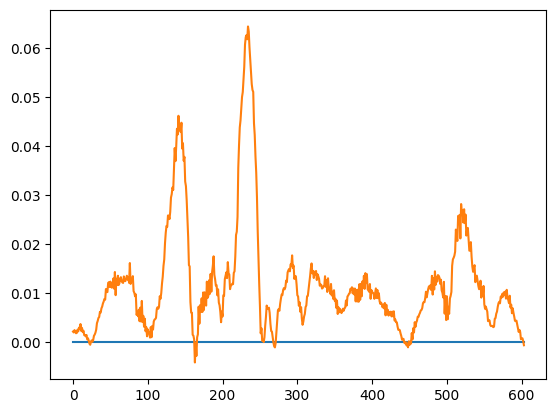

In [11]:
plt.plot(epz_model_interp[110,5,:])
plt.plot(epz_eachyr[64,5,:])

In [12]:
hh_model = np.zeros(zdim)
dz = 100000/(zdim-1)
for k in range(zdim):
    hh_model[k] = k*dz

edz_model = np.zeros_like(epz_model_interp)
for z in range(1,zdim-1):
    edz_model[z,:,:] =  -np.exp(hh_model[z]/hh) * (epz_model_interp[z+1,:,:] - epz_model_interp[z-1,:,:])/dz/2 

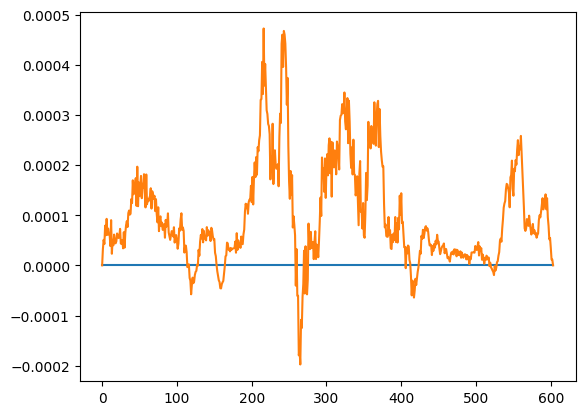

In [13]:
plt.plot(edz_model[110,15,:])
plt.plot(edz_a_eachyr[64,15,:])

In [14]:
#-----------------
# read netCDF files
#-----------------

#filename1 = 'ur60n10hPa.nc'
#filename2 = 'ub60n10hPa.nc'
filename1 = '/scratch/smliu01/1d_model/archive/ur60n10hPa.nc'
filename2 = '/scratch/smliu01/1d_model/archive/ub60n10hPa.nc'

ncin1 = Dataset(filename1, 'r', format='NETCDF4') 
ncin2 = Dataset(filename2, 'r', format='NETCDF4')

uref = ncin1.variables['uref'] 
uref = (np.array(uref))
ubar = ncin2.variables['ubar'] 
ubar = (np.array(ubar))
print(uref.shape)
print(ubar.shape)

i=0
urp = np.zeros((42,992))
ubp = np.zeros((42,992))
days = np.zeros(8)
dddd = np.zeros((42,992))
date = dddd.tolist()

month = [9,10,11,0,1,2,3,4]

time = ['00','06','12','18']
months = ['10','11','12','01','02','03','04','05']
dates = ['01','02','03','04','05','06','07','08','09','10',   \
         '11','12','13','14','15','16','17','18','19',        \
        '20','21','22','23','24','25','26','27','28','29','30','31']

while(i<42):
    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if uref[j,month[m],i]!=0:
                    urp[i,k] = uref[j,month[m],i]
                    date[i][k] = str(i+1979)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            else:
                if uref[j,month[m],i+1]!=0:
                    urp[i,k] = uref[j,month[m],i+1]
                    date[i][k] = str(i+1980)+'/'+str(months[m])+'/'+str(dates[int(j/4)])+'/'+str(time[j%4])
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #urp[urp==0]=np.nan


    m=0
    k=0
    while(m<8):
        j=0
        while(j<124):
            if m<3:
                if ubar[j,month[m],i]!=0:
                    ubp[i,k] = ubar[j,month[m],i]
                    k=k+1
            else:
                if ubar[j,month[m],i+1]!=0:
                    ubp[i,k] = ubar[j,month[m],i+1]
                    k=k+1
            j=j+1
        days[m]=k
        m=m+1
    #ubp[ubp==0]=np.nan

    i=i+1


(124, 12, 43)
(124, 12, 43)


In [15]:
# %% ===== New core cell: imports + helpers + class + grid search =====
import os
import csv
import time
import math
import subprocess
import warnings
import numpy as np
from pathlib import Path
from netCDF4 import Dataset
from scipy.optimize import minimize
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore", message=".*converting a masked element to nan.*")

# ============================================================
# user settings
# ============================================================
WORK_DIR  = "/nas/smliu01/graybox"
YEARS     = 42

OUT_U_BASENAME  = "uout"   # var: ubar
OUT_A_BASENAME  = "aout"   # var: fawa
OUT_UR_BASENAME = "urout"  # var: uref

KMAX_MODEL    = 501
MODEL_K_10HPA = 110

W_U, W_A, W_R = 2/5, 2/5, 1/5
DIST_FRAC     = 0.30
JSD_BINS      = 32

# SSW penalty
SSW_TARGET   = 22
SSW_WEIGHT   = 0.3
SSW_DMAX_REF = 992

# Powell bounds
BETA_BOUNDS = (0.0, 1.0)
STAU_BOUNDS = (0.5, 1.8)

# ============================================================
# tag / path helpers
# ============================================================
def tag_from_params(beta, s_tau, damp1_days, u_thres, flux_extra):
    b  = f"{beta:.2f}".replace(".", "p")
    s  = f"{s_tau:.1f}".replace(".", "p")
    d1 = f"{int(round(damp1_days))}"
    ut = f"{u_thres:.1f}".replace(".", "p")
    fx = f"{flux_extra:.1f}".replace(".", "p")
    return f"b{b}s{s}_d{d1}_u{ut}f{fx}"

def _tag_paths(workdir, outtag):
    p_u  = Path(workdir) / f"{OUT_U_BASENAME}_{outtag}.nc"
    p_a  = Path(workdir) / f"{OUT_A_BASENAME}_{outtag}.nc"
    p_ur = Path(workdir) / f"{OUT_UR_BASENAME}_{outtag}.nc"
    return p_u, p_a, p_ur

def _plain_paths(workdir):
    p_u  = Path(workdir) / f"{OUT_U_BASENAME}.nc"
    p_a  = Path(workdir) / f"{OUT_A_BASENAME}.nc"
    p_ur = Path(workdir) / f"{OUT_UR_BASENAME}.nc"
    return p_u, p_a, p_ur

# ============================================================
# run model once
# NOTE:
#   run.sh 
#   ./run.sh beta s_tau damp1_days muC n_ep sigma_ep tag
# ============================================================
def run_once(beta, s_tau, damp1_days, u_thres, flux_extra,
             outtag=None, workdir=WORK_DIR, timeout_sec=43200, force=False):

    if outtag is None:
        outtag = tag_from_params(beta, s_tau, damp1_days, u_thres, flux_extra)

    p_u_tag, p_a_tag, p_ur_tag = _tag_paths(workdir, outtag)

    if (not force) and p_u_tag.exists() and p_a_tag.exists() and p_ur_tag.exists():
        return str(p_u_tag), str(p_a_tag), str(p_ur_tag)

    cmd = (
        f'./run.sh {beta} {s_tau} {damp1_days} {u_thres} {flux_extra} '
        f'0.5 2.2e-3 3.0 0.25 {outtag}'
    )

    res = subprocess.run(
        ["bash", "-lc", cmd],
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=timeout_sec,
    )

    if res.returncode != 0:
        print("=== STDOUT ===\n", res.stdout)
        print("=== STDERR ===\n", res.stderr)
        raise RuntimeError(f"Model run failed ({outtag})")

    if p_u_tag.exists() and p_a_tag.exists() and p_ur_tag.exists():
        return str(p_u_tag), str(p_a_tag), str(p_ur_tag)

    # backward-compatible fallback
    p_u_plain, p_a_plain, p_ur_plain = _plain_paths(workdir)
    if p_u_plain.exists() and p_a_plain.exists() and p_ur_plain.exists():
        return str(p_u_plain), str(p_a_plain), str(p_ur_plain)

    print("=== STDOUT ===\n", res.stdout)
    print("=== STDERR ===\n", res.stderr)
    raise FileNotFoundError(f"Missing outputs after run: {outtag}")

# ============================================================
# IO helpers
# ============================================================
def _read_time_height(nc_path, varname, years):
    with Dataset(nc_path, "r") as ds:
        v = ds.variables[varname][:]
        dims = getattr(ds.variables[varname], "dimensions", None)

    if v.ndim != 2:
        raise ValueError(f"{nc_path}:{varname} ndim={v.ndim}, expect 2")

    n0, n1 = v.shape

    if n0 % years == 0 and n1 % years != 0:
        arr = v
        time_len, kmax_found = n0, n1
    elif n1 % years == 0 and n0 % years != 0:
        arr = v.T
        time_len, kmax_found = n1, n0
    else:
        if n1 == KMAX_MODEL and n0 % years == 0:
            arr = v
            time_len, kmax_found = n0, n1
        elif n0 == KMAX_MODEL and n1 % years == 0:
            arr = v.T
            time_len, kmax_found = n1, n0
        else:
            raise ValueError(
                f"Cannot infer dims {nc_path}:{varname}, shape={v.shape}, dims={dims}"
            )

    n_per_year = time_len // years
    return arr, n_per_year, kmax_found

def load_model_10hpa(u_nc, a_nc, ur_nc, years=YEARS, k10=MODEL_K_10HPA):
    u_arr, n_per_year_u, kmax_u = _read_time_height(u_nc, "ubar", years)
    a_arr, n_per_year_a, kmax_a = _read_time_height(a_nc, "fawa", years)
    r_arr, n_per_year_r, kmax_r = _read_time_height(ur_nc, "uref", years)

    u_arr = u_arr.reshape(years, n_per_year_u, kmax_u)
    a_arr = a_arr.reshape(years, n_per_year_a, kmax_a)
    r_arr = r_arr.reshape(years, n_per_year_r, kmax_r)

    t_end = int(n_per_year_u * 7 / 8)   # Oct-Apr

    u_clim = u_arr.mean(axis=0)[:, k10][:t_end]
    a_clim = a_arr.mean(axis=0)[:, k10][:t_end]
    r_clim = r_arr.mean(axis=0)[:, k10][:t_end]

    u_flat = u_arr[:, :t_end, k10].ravel()
    a_flat = a_arr[:, :t_end, k10].ravel()
    r_flat = r_arr[:, :t_end, k10].ravel()

    return (u_clim, a_clim, r_clim, t_end), (u_flat, a_flat, r_flat)

def load_model_u10_raw_for_ssw(u_nc, years=YEARS, k10=MODEL_K_10HPA):
    """
     10 hPa ubar t_end=7/8 
    :
      u10_2d_raw : shape = (years, n_per_year_raw)
      n_per_year_raw
    """
    u_arr, n_per_year_u, kmax_u = _read_time_height(u_nc, "ubar", years)
    u_arr = u_arr.reshape(years, n_per_year_u, kmax_u)

    u10_2d_raw = u_arr[:, :, k10].astype(np.float64)
    return u10_2d_raw, n_per_year_u

def interp_to(x, n_target):
    x0 = np.linspace(0.0, 1.0, len(x), endpoint=False)
    x1 = np.linspace(0.0, 1.0, n_target, endpoint=False)
    return np.interp(x1, x0, x)

def _zscore(x):
    x = np.asarray(x, dtype=np.float64)
    m = x.mean()
    s = x.std()
    return (x - m) / s if s > 0 else x * 0.0

def distribution_loss(model_vals, era_vals, bins=JSD_BINS):
    xm = _zscore(np.ravel(model_vals))
    xe = _zscore(np.ravel(era_vals))

    emd = float(wasserstein_distance(xm, xe))

    lo = float(min(xm.min(), xe.min()))
    hi = float(max(xm.max(), xe.max()))

    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo == hi):
        jsd = 0.0
    else:
        hist_m, edges = np.histogram(xm, bins=bins, range=(lo, hi), density=True)
        hist_e, _     = np.histogram(xe, bins=edges, density=True)
        eps = 1e-12
        pm = hist_m + eps
        pe = hist_e + eps
        pm = pm / pm.sum()
        pe = pe / pe.sum()
        jsd = float(jensenshannon(pm, pe))

    return emd + jsd

# ============================================================
# SSW helpers
# ============================================================
def model_day_to_month_day(day_index):
    month_lengths = [31, 30, 31, 31, 28, 31, 30]  # Oct-Apr
    month_names   = ["10", "11", "12", "01", "02", "03", "04"]
    total_days    = sum(month_lengths)

    d = int(round(day_index))
    if d < 0:
        d = 0
    if d >= total_days:
        d = total_days - 1

    for mlen, mname in zip(month_lengths, month_names):
        if d < mlen:
            return mname, d + 1
        d -= mlen

    return month_names[-1], month_lengths[-1]

def build_model_calendar_2d(years, n_per_year):
    scale_model      = n_per_year / float(SSW_DMAX_REF)
    steps_per_day_md = 4.0 * scale_model

    date_2d_model = np.empty((years, n_per_year), dtype=object)
    for iy in range(years):
        for step in range(n_per_year):
            day_since_oct1 = step / steps_per_day_md
            day_int = int(round(day_since_oct1))
            mm_str, dd_int = model_day_to_month_day(day_int)
            date_2d_model[iy, step] = f"0000-{mm_str}-{dd_int:02d}"

    return date_2d_model



def count_ssw_events_from_u10(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=SSW_DMAX_REF,
    min_gap_days=10,
    min_gap_onset_days=20,
    min_duration_days=2,
    use_djf_only=False,
    return_debug=False,
    date_2d=None,
    enforce_march10_cutoff=True,
    exclude_onset_indices=None,
):
    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    #  >= 2 
    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end   = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))

    # exclude  1-based  onset index
    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    #  March 10 cutoff 
    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])
            mm = int(dstr[5:7])
            dd = int(dstr[8:10])

            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)

# ============================================================
# main greybox class
# ============================================================
class GreyBoxBetaSTau:
    def __init__(self, years,
                 era_ubar_eachyr, era_fawa_eachyr, era_uref_eachyr=None,
                 era_k_index=64, model_k_index=MODEL_K_10HPA,
                 w_u=W_U, w_a=W_A, w_r=W_R,
                 dist_frac=DIST_FRAC, cache=True,
                 damp1_days=5.0, u_thres=9.0, flux_extra=16.0):


        self.years = years
        self.era_k = era_k_index
        self.model_k = model_k_index

        self.use_cache = cache
        self._cache = {}

        self.damp1_days = float(damp1_days)
        self.u_thres    = float(u_thres)
        self.flux_extra = float(flux_extra)

        self.w_u = float(w_u)
        self.w_a = float(w_a)
        self.w_r = float(w_r) if era_uref_eachyr is not None else 0.0
        self.dist_frac = float(dist_frac)

        assert era_ubar_eachyr.ndim == 3 and era_fawa_eachyr.ndim == 3
        assert era_ubar_eachyr.shape == era_fawa_eachyr.shape

        era_u_levtime = era_ubar_eachyr.mean(axis=1)
        era_a_levtime = era_fawa_eachyr.mean(axis=1)

        t_end = int(604 * 7 / 8)

        self.era_u_10_clim = era_u_levtime[self.era_k, :t_end].astype(np.float64)
        self.era_a_10_clim = era_a_levtime[self.era_k, :t_end].astype(np.float64)

        self.era_u_10_all = era_ubar_eachyr[self.era_k, :, :t_end].ravel().astype(np.float64)
        self.era_a_10_all = era_fawa_eachyr[self.era_k, :, :t_end].ravel().astype(np.float64)

        if era_uref_eachyr is not None:
            assert era_uref_eachyr.shape == era_ubar_eachyr.shape
            era_r_levtime = era_uref_eachyr.mean(axis=1)
            self.era_r_10_clim = era_r_levtime[self.era_k, :t_end].astype(np.float64)
            self.era_r_10_all  = era_uref_eachyr[self.era_k, :, :t_end].ravel().astype(np.float64)
        else:
            self.era_r_10_clim = None
            self.era_r_10_all  = None

    def simulate(self, beta, s_tau):
        key = (
            round(beta, 6),
            round(s_tau, 6),
            round(self.damp1_days, 6),
            round(self.u_thres, 6),
            round(self.flux_extra, 6),
        )

        if self.use_cache and key in self._cache:
            return self._cache[key]

        outtag = tag_from_params(beta, s_tau, self.damp1_days, self.u_thres, self.flux_extra)

        u_nc, a_nc, ur_nc = run_once(
            beta, s_tau, self.damp1_days, self.u_thres, self.flux_extra,
            outtag=outtag, workdir=WORK_DIR
        )

        (u_clim, a_clim, r_clim, n_per_year), (u_all, a_all, r_all) = load_model_10hpa(
            u_nc, a_nc, ur_nc, years=self.years, k10=self.model_k
        )

        u10_raw_2d, n_per_year_raw = load_model_u10_raw_for_ssw(
            u_nc, years=self.years, k10=self.model_k
        )

        out = (
            u_clim, a_clim, r_clim, n_per_year,
            u_all, a_all, r_all,
            u10_raw_2d, n_per_year_raw,
            outtag
        )

        if self.use_cache:
            self._cache[key] = out

        return out


    def residuals(self, x):
        beta, s_tau = float(x[0]), float(x[1])

        beta  = min(1.5, max(0.0, beta))
        s_tau = min(3.0, max(0.5, s_tau))

        (u_clim, a_clim, r_clim, n_per_year,
        u_all, a_all, r_all,
        u10_raw_2d, n_per_year_raw,
        _) = self.simulate(beta, s_tau)

        era_u = self.era_u_10_clim if len(self.era_u_10_clim) == n_per_year else interp_to(self.era_u_10_clim, n_per_year)
        era_a = self.era_a_10_clim if len(self.era_a_10_clim) == n_per_year else interp_to(self.era_a_10_clim, n_per_year)

        rmse_u = float(np.sqrt(np.mean((u_clim - era_u) ** 2)))
        rmse_a = float(np.sqrt(np.mean((a_clim - era_a) ** 2)))

        if self.w_r > 0.0 and self.era_r_10_clim is not None:
            era_r = self.era_r_10_clim if len(self.era_r_10_clim) == n_per_year else interp_to(self.era_r_10_clim, n_per_year)
            rmse_r = float(np.sqrt(np.mean((r_clim - era_r) ** 2)))
        else:
            rmse_r = 0.0

        dist_u = distribution_loss(u_all, self.era_u_10_all, bins=JSD_BINS)
        dist_a = distribution_loss(a_all, self.era_a_10_all, bins=JSD_BINS)
        dist_r = distribution_loss(r_all, self.era_r_10_all, bins=JSD_BINS) if (self.w_r > 0.0 and self.era_r_10_all is not None) else 0.0

        Lu = (1.0 - self.dist_frac) * rmse_u + self.dist_frac * dist_u * 100.0
        La = (1.0 - self.dist_frac) * rmse_a + self.dist_frac * dist_a * 100.0
        Lr = (1.0 - self.dist_frac) * rmse_r + self.dist_frac * dist_r * 100.0

        def model_u10_to_era5_like_inputs(
            u10_2d_raw,          # shape = (years, steps_per_year_src)
            start_year=1979
        ):
            """
             10 hPa  ERA5-like 
            ubp:  shape = (years, 992)
            date: shape = (years, 992),  'YYYY/MM/DD/HH'
            """
            u10_2d_raw = np.asarray(u10_2d_raw, dtype=float)
            years, steps_per_year_src = u10_2d_raw.shape

            tgt_len = 992
            src_x = np.arange(steps_per_year_src, dtype=float)
            tgt_x = np.linspace(0, steps_per_year_src - 1, tgt_len)

            ubp = np.empty((years, tgt_len), dtype=float)
            for y in range(years):
                ubp[y] = np.interp(tgt_x, src_x, u10_2d_raw[y])

            time4 = ['00', '06', '12', '18']
            months = ['10', '11', '12', '01', '02', '03', '04', '05']
            days31 = [f"{d:02d}" for d in range(1, 32)]

            date = [[None] * tgt_len for _ in range(years)]
            for y in range(years):
                k = 0
                for mi, mm in enumerate(months):
                    year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
                    for dd in days31:
                        for hh in time4:
                            date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                            k += 1

            return ubp, np.array(date, dtype=object)

        try:
            # date_2d_model = build_model_calendar_2d(self.years, n_per_year)

            # n_ssw, events, dbg = count_ssw_events_from_u10(
            #     u_all_flat=u_all,
            #     n_per_year=n_per_year,
            #     years=self.years,
            #     dmax_ref=SSW_DMAX_REF,
            #     min_gap_days=10,
            #     min_gap_onset_days=20,
            #     min_duration_days=2,
            #     use_djf_only=False,
            #     return_debug=True,
            #     date_2d=date, #date_2d_model,
            #     enforce_march10_cutoff=True,
            #     exclude_onset_indices=None,
            # )

            #  992 /
            ubp_model, date_model = model_u10_to_era5_like_inputs(
                u10_2d_raw=u10_raw_2d,
                start_year=1979
            )
                      
            n_ssw, events, dbg = count_ssw_events_from_u10(
                u_all_flat=ubp_model.reshape(-1),
                n_per_year=992,
                years=self.years,
                dmax_ref=992,
                min_gap_days=10,
                min_gap_onset_days=20,
                min_duration_days=2,
                use_djf_only=False,
                return_debug=True,
                date_2d=date,
                enforce_march10_cutoff=True,
                exclude_onset_indices=None,
            )

        except Exception as e:
            print(f"[warn] SSW counting failed: {e}")
            n_ssw = np.nan

        if  n_ssw == 0:
            penalty_ssw = 100
        elif np.isfinite(n_ssw):
            penalty_ssw = SSW_WEIGHT * abs(n_ssw - SSW_TARGET)
        else:
            penalty_ssw = 0.0

        self.last_n_ssw = n_ssw
        self.last_ssw_penalty = penalty_ssw

        loss = self.w_u * Lu + self.w_a * La + self.w_r * Lr + penalty_ssw

        print(
            f"[try] beta={beta:.3f}, s_tau={s_tau:.3f} | "
            f"d1={self.damp1_days:.1f}, u_thres={self.u_thres:.4e}, "
            f"flux_extra={self.flux_extra:.3f} | "
            f"Urmse={rmse_u:.4f}, Armse={rmse_a:.4f}, Rrmse={rmse_r:.4f}, "
            f"Udist={dist_u:.4f}, Adist={dist_a:.4f}, Rdist={dist_r:.4f}, "
            f"loss={loss:.5f}, ssw={n_ssw}",
            flush=True
        )

        return loss

    def estimate_parameters(self, x0,
                            bounds=(BETA_BOUNDS, STAU_BOUNDS),
                            method="Powell", maxiter=50):

        res = minimize(
            fun=self.residuals,
            x0=np.array(x0, dtype=float),
            method=method,
            bounds=bounds,
            options={"maxiter": maxiter, "disp": True},
        )
        self.params_ = res.x
        self.fun_    = res.fun
        self.result_ = res
        return res

# ============================================================
# grid / csv helpers
# ============================================================
def param_grid():
    damp1_list = [4.0, 5.0,6.0]                         #[5.0,6.0]                       #
    uth_list   = [4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,11.0,12.0]         #[9.0, 10.0,11.0,12.0]           #
    fx_list    = [13.0, 14.0, 15.0, 16.0, 17.0]         #[16.0, 17.0]  #  

    for damp1_days in damp1_list:
        for u_thres in uth_list:
            for flux_extra in fx_list:
                yield float(damp1_days), float(u_thres), float(flux_extra)

def _save_results_csv(rows, path):
    keys = [
        "damp1_days", "u_thres", "flux_extra",
        "beta", "s_tau", "loss",
        "n_ssw", "ssw_penalty",
        "x0_beta", "x0_s_tau", "grid_loss",
        "tag", "status"
    ]
    os.makedirs(os.path.dirname(path), exist_ok=True)
    file_exists = os.path.exists(path)
    write_header = (not file_exists) or (os.stat(path).st_size == 0)

    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys)
        if write_header:
            w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in keys})

def _save_grid_evals_csv(rows, path):
    keys = ["damp1_days", "u_thres", "flux_extra", "beta", "s_tau", "loss"]
    os.makedirs(os.path.dirname(path), exist_ok=True)
    file_exists = os.path.exists(path)
    write_header = (not file_exists) or (os.stat(path).st_size == 0)

    with open(path, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys)
        if write_header:
            w.writeheader()
        for r in rows:
            w.writerow({k: r.get(k, "") for k in keys})

def _already_done_from_csv(csv_path):
    done = set()
    if csv_path and Path(csv_path).exists():
        with open(csv_path, "r") as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    key = (
                        float(row["damp1_days"]),
                        float(row["u_thres"]),
                        float(row["flux_extra"]),
                    )
                    done.add(key)
                except Exception:
                    continue
    return done

def load_best_from_csv(csv_path, metric="loss", valid_status=("ok", "opt_fail")):
    best_row = None
    best_val = np.inf

    if not csv_path or (not Path(csv_path).exists()):
        return None

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                status = str(row.get("status", "")).strip()
                if valid_status is not None and status not in valid_status:
                    continue

                val = float(row[metric])
                if val < best_val:
                    best_val = val
                    best_row = row
            except Exception:
                continue

    return best_row

def coarse_grid_for_x0(gb, damp1_days, u_thres, flux_extra,
                       beta_grid=None, stau_grid=None,
                       grid_csv_path=None):

    if beta_grid is None:
        beta_grid = np.linspace(0.2, 0.8, 4)
    if stau_grid is None:
        stau_grid = np.linspace(0.5, 1.5, 3)

    best = (np.inf, None, None)

    for b in beta_grid:
        for s in stau_grid:
            val = gb.residuals([b, s])

            if grid_csv_path is not None:
                row = {
                    "damp1_days": float(damp1_days),
                    "u_thres": float(u_thres),
                    "flux_extra": float(flux_extra),
                    "beta": float(b),
                    "s_tau": float(s),
                    "loss": float(val),
                    "n_ssw": getattr(gb, "last_n_ssw", np.nan),
                    "ssw_penalty": getattr(gb, "last_ssw_penalty", np.nan),
                }
                _save_grid_evals_csv([row], grid_csv_path)

            if val < best[0]:
                best = (val, b, s)
                print(f"[grid] loss={val:.5f} at beta={b:.3f}, s_tau={s:.3f}")

    return [best[1], best[2]], best[0]

# ============================================================
# full outer-loop grid search
# ============================================================
def run_grid_search(ubar_eachyr, fawa_eachyr, uref_eachyr=None,
                    save_csv_path=None, grid_csv_path=None,
                    maxiter=50, cache=True,
                    resume=True, sleep_between=0):

    results = []
    global_best = None
    best_metric = np.inf

    done_quads = _already_done_from_csv(save_csv_path) if resume else set()

    for damp1_days, u_thres, flux_extra in param_grid():
        quad = (damp1_days, u_thres, flux_extra)

        if resume and quad in done_quads:
            print(
                f"[skip:CSV] d1={damp1_days}, u_thres={u_thres}, "
                f"flux_extra={flux_extra}"
            )
            continue

        print(
            f"\n===== Discrete combo: "
            f"d1={damp1_days}, u_thres={u_thres}, flux_extra={flux_extra} ====="
        )

        try:
            gb = GreyBoxBetaSTau(
                years=YEARS,
                era_ubar_eachyr=ubar_eachyr,
                era_fawa_eachyr=fawa_eachyr,
                era_uref_eachyr=uref_eachyr if uref_eachyr is not None else None,
                era_k_index=64,
                model_k_index=110,
                w_u=W_U, w_a=W_A, w_r=W_R,
                dist_frac=DIST_FRAC,
                cache=cache,
                damp1_days=damp1_days,
                u_thres=u_thres,
                flux_extra=flux_extra,
            )

            x0, grid_loss = coarse_grid_for_x0(
                gb,
                damp1_days=damp1_days,
                u_thres=u_thres,
                flux_extra=flux_extra,
                grid_csv_path=grid_csv_path,
            )

            res = gb.estimate_parameters(
                x0=x0,
                bounds=(BETA_BOUNDS, STAU_BOUNDS),
                method="Powell",
                maxiter=maxiter,
            )

            beta_opt, stau_opt = float(res.x[0]), float(res.x[1])
            tag = tag_from_params(beta_opt, stau_opt, damp1_days, u_thres, flux_extra)

            row = {
                "damp1_days": float(damp1_days),
                "u_thres": float(u_thres),
                "flux_extra": float(flux_extra),
                "beta": beta_opt,
                "s_tau": stau_opt,
                "loss": float(res.fun),
                "n_ssw": gb.last_n_ssw,
                "ssw_penalty": gb.last_ssw_penalty,
                "x0_beta": float(x0[0]),
                "x0_s_tau": float(x0[1]),
                "grid_loss": float(grid_loss),
                "tag": tag,
                "status": "ok" if getattr(res, "success", False) else "opt_fail",
            }

            results.append(row)

            if save_csv_path is not None:
                _save_results_csv([row], save_csv_path)

            # metric = float(grid_loss)
            metric = float(res.fun)
            if metric < best_metric:
                best_metric = metric
                global_best = row.copy()

            print(
                f"[done] d1={damp1_days}, u_thres={u_thres:.4e}, flux_extra={flux_extra:.3f} | "
                f"beta={beta_opt:.4f}, s_tau={stau_opt:.4f}, "
                f"grid_loss={grid_loss:.5f}, final_loss={res.fun:.5f}"
            )

        except Exception as e:
            print(
                f"[FAILED] d1={damp1_days}, u_thres={u_thres:.4e}, "
                f"flux_extra={flux_extra:.3f}: {e}"
            )

            fail_row = {
                "damp1_days": float(damp1_days),
                "u_thres": float(u_thres),
                "flux_extra": float(flux_extra),
                "beta": "",
                "s_tau": "",
                "loss": "",
                "n_ssw": "",
                "ssw_penalty": "",
                "x0_beta": "",
                "x0_s_tau": "",
                "grid_loss": "",
                "tag": "",
                "status": f"failed: {e}",
            }

            results.append(fail_row)
            if save_csv_path is not None:
                _save_results_csv([fail_row], save_csv_path)

        if sleep_between > 0:
            time.sleep(sleep_between)

    return global_best

# ============================================================
# run cell
# Assumes you already created:
#   ubar_eachyr
#   fawa_eachyr
#   uref_eachyr   (or set to None)
# ============================================================
SAVE_CSV = "/nas/smliu01/graybox_results/graybox_fullgrid_new_epflux.csv"
GRID_CSV = "/nas/smliu01/graybox_results/graybox_grid_new_epflux.csv"

os.makedirs(Path(SAVE_CSV).parent, exist_ok=True)
os.makedirs(Path(GRID_CSV).parent, exist_ok=True)

# best = run_grid_search(
#     ubar_eachyr=ubar_eachyr,
#     fawa_eachyr=fawa_eachyr,
#     uref_eachyr=uref_eachyr,   #  uref None
#     save_csv_path=SAVE_CSV,
#     grid_csv_path=GRID_CSV,
#     maxiter=50,
#     cache=True,
#     resume=True,
#     sleep_between=0,
# )

# print("\n================= EXPERIMENT DONE =================")
# print("Best result:")
# print(best)
# print(f"Results saved to: {SAVE_CSV}")
# print(f"Grid evals saved to: {GRID_CSV}")

_ = run_grid_search(
    ubar_eachyr=ubar_eachyr,
    fawa_eachyr=fawa_eachyr,
    uref_eachyr=uref_eachyr,
    save_csv_path=SAVE_CSV,
    grid_csv_path=GRID_CSV,
    maxiter=50,
    cache=True,
    resume=True,
    sleep_between=0,
)

best = load_best_from_csv(SAVE_CSV, metric="loss")

print("\n================= EXPERIMENT DONE =================")
print("Best result in full CSV by final loss:")
print(best)
print(f"Results saved to: {SAVE_CSV}")
print(f"Grid evals saved to: {GRID_CSV}")

best_grid = load_best_from_csv(SAVE_CSV, metric="grid_loss")
print("Best result in full CSV by grid loss:")
print(best_grid)

[skip:CSV] d1=4.0, u_thres=4.0, flux_extra=13.0
[skip:CSV] d1=4.0, u_thres=4.0, flux_extra=14.0
[skip:CSV] d1=4.0, u_thres=4.0, flux_extra=15.0
[skip:CSV] d1=4.0, u_thres=4.0, flux_extra=16.0
[skip:CSV] d1=4.0, u_thres=4.0, flux_extra=17.0
[skip:CSV] d1=4.0, u_thres=5.0, flux_extra=13.0
[skip:CSV] d1=4.0, u_thres=5.0, flux_extra=14.0
[skip:CSV] d1=4.0, u_thres=5.0, flux_extra=15.0
[skip:CSV] d1=4.0, u_thres=5.0, flux_extra=16.0
[skip:CSV] d1=4.0, u_thres=5.0, flux_extra=17.0
[skip:CSV] d1=4.0, u_thres=6.0, flux_extra=13.0
[skip:CSV] d1=4.0, u_thres=6.0, flux_extra=14.0
[skip:CSV] d1=4.0, u_thres=6.0, flux_extra=15.0
[skip:CSV] d1=4.0, u_thres=6.0, flux_extra=16.0
[skip:CSV] d1=4.0, u_thres=6.0, flux_extra=17.0
[skip:CSV] d1=4.0, u_thres=7.0, flux_extra=13.0
[skip:CSV] d1=4.0, u_thres=7.0, flux_extra=14.0
[skip:CSV] d1=4.0, u_thres=7.0, flux_extra=15.0
[skip:CSV] d1=4.0, u_thres=7.0, flux_extra=16.0
[skip:CSV] d1=4.0, u_thres=7.0, flux_extra=17.0
[skip:CSV] d1=4.0, u_thres=8.0, flux_ext

算已有文件的loss

In [16]:
# def detailed_loss_from_three_nc(u_nc, a_nc, ur_nc,
#                                 ubar_eachyr, fawa_eachyr, uref_eachyr=None,
#                                 years=YEARS,
#                                 era_k_index=64, model_k_index=MODEL_K_10HPA,
#                                 w_u=W_U, w_a=W_A, w_r=W_R, dist_frac=DIST_FRAC):
#     """
#      nc  (uout/aout/urout) GreyBoxBetaSTau.residuals
#      loss

#     
#     ----
#     u_nc, a_nc, ur_nc : str  Path
#          uout_*.nc, aout_*.nc, urout_*.nc
#          radiative wind ur_nc=None  uref_eachyr=None
#     ubar_eachyr, fawa_eachyr, uref_eachyr : ERA  (year × lev × time)
#     """

#     # === 1.  ===
#     (u_clim, a_clim, r_clim, n_per_year), (u_all, a_all, r_all) = load_model_10hpa(
#         str(u_nc), str(a_nc), str(ur_nc) if ur_nc is not None else str(u_nc),
#         years=years, k10=model_k_index
#     )

#     # === 2.  ERA GreyBoxBetaSTau.__init__  ===
#     assert ubar_eachyr.ndim == 3 and fawa_eachyr.ndim == 3
#     assert ubar_eachyr.shape == fawa_eachyr.shape

#     era_u_levtime = ubar_eachyr.mean(axis=1)
#     era_a_levtime = fawa_eachyr.mean(axis=1)

#     #  10  4 604 * 7/8 ≈ 528
#     t_end_era = int(604 * 7 / 8)

#     era_u_10_clim = era_u_levtime[era_k_index, :t_end_era].astype(np.float64)
#     era_a_10_clim = era_a_levtime[era_k_index, :t_end_era].astype(np.float64)

#     era_u_10_all = ubar_eachyr[era_k_index, :, :t_end_era].ravel().astype(np.float64)
#     era_a_10_all = fawa_eachyr[era_k_index, :, :t_end_era].ravel().astype(np.float64)

#     # u_clim, a_clim  load_model_10hpa  t_end 
#     n_model = len(u_clim)

#     if len(era_u_10_clim) == n_model:
#         era_u = era_u_10_clim
#         era_a = era_a_10_clim
#     else:
#         era_u = interp_to(era_u_10_clim, n_model)
#         era_a = interp_to(era_a_10_clim, n_model)

#     # === 3. RMSE  ===
#     rmse_u = float(np.sqrt(np.mean((u_clim - era_u) ** 2)))
#     rmse_a = float(np.sqrt(np.mean((a_clim - era_a) ** 2)))

#     rmse_r = 0.0
#     dist_r = 0.0
#     use_r  = (uref_eachyr is not None) and (w_r > 0.0) and (ur_nc is not None)

#     if use_r:
#         assert uref_eachyr.shape == ubar_eachyr.shape
#         era_r_levtime = uref_eachyr.mean(axis=1)
#         era_r_10_clim = era_r_levtime[era_k_index, :t_end_era].astype(np.float64)
#         era_r_10_all  = uref_eachyr[era_k_index, :, :t_end_era].ravel().astype(np.float64)

#         if len(era_r_10_clim) == len(r_clim):
#             era_r = era_r_10_clim
#         else:
#             era_r = interp_to(era_r_10_clim, len(r_clim))

#         rmse_r = float(np.sqrt(np.mean((r_clim - era_r) ** 2)))

#     # === 4. distribution loss  ===
#     dist_u = distribution_loss(u_all, era_u_10_all, bins=JSD_BINS)
#     dist_a = distribution_loss(a_all, era_a_10_all, bins=JSD_BINS)
#     if use_r:
#         dist_r = distribution_loss(r_all, era_r_10_all, bins=JSD_BINS)

#     # === 5. Lu / La / Lr ===
#     Lu = (1.0 - dist_frac) * rmse_u + dist_frac * dist_u * 100.0
#     La = (1.0 - dist_frac) * rmse_a + dist_frac * dist_a * 100.0
#     Lr = (1.0 - dist_frac) * rmse_r + dist_frac * dist_r * 100.0

#     # === 6.  penalty residuals  ===
#     # penalty = 0.0
#     # if (u_all < 0).sum() < 560:
#     #     penalty = 100.0

#     # === 7.  loss ===
#     if not use_r:
#         w_r_eff = 0.0
#     else:
#         w_r_eff = w_r

#     loss = w_u * Lu + w_a * La + w_r_eff * Lr + penalty

#     # === 8.  summary ===
#     print("=== detailed loss report (three nc) ===")
#     print(f"rmse_u={rmse_u:.4f}, rmse_a={rmse_a:.4f}, rmse_r={rmse_r:.4f}")
#     print(f"dist_u={dist_u:.4f}, dist_a={dist_a:.4f}, dist_r={dist_r:.4f}")
#     print(f"Lu={Lu:.4f}, La={La:.4f}, Lr={Lr:.4f}, penalty={penalty:.1f}")
#     print(f"TOTAL loss = {loss:.5f}")
#     print("=======================================")

#     return {
#         "loss": loss,
#         "Lu": Lu, "La": La, "Lr": Lr,
#         "rmse_u": rmse_u, "rmse_a": rmse_a, "rmse_r": rmse_r,
#         "dist_u": dist_u, "dist_a": dist_a, "dist_r": dist_r,
#         "penalty": penalty,
#         "n_per_year_model": int(n_per_year),
#         "len_u_clim": int(len(u_clim)),
#         "t_end_era": int(t_end_era),
#     }


In [17]:
# from pathlib import Path

# base_dir = Path("/mnt/winds/home/smliu01/1.reproduce_nfl20_10.2020-1.2021/1d_refine/1d_para/graybox_mixing")
# tag = "b0p79s2p0_d4u12f18" #'b0p24s0p5_d5u10f15'#"b0p79s2p0_d5u12f18"

# u_nc  = base_dir / f"uout_{tag}.nc"
# a_nc  = base_dir / f"aout_{tag}.nc"
# ur_nc = base_dir / f"urout_{tag}.nc"   #  ur None

# metrics = detailed_loss_from_three_nc(
#     u_nc=u_nc,
#     a_nc=a_nc,
#     ur_nc=ur_nc,
#     ubar_eachyr=ubar_eachyr,
#     fawa_eachyr=fawa_eachyr,
#     uref_eachyr=uref_eachyr   #  radiative None
# )

# print("TOTAL loss =", metrics["loss"])
# print(metrics)



画优化图

In [18]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def explore_full_trace_for_combo(
    d1, uth, fx,
    ubar_eachyr, fawa_eachyr, uref_eachyr,
    beta_grid=None, stau_grid=None,
    maxiter=50,
    bounds=((0.0, 1.0), (0.5, 1.8)),
    cache=True,
):
    """
     (d1, uth, fx) 
      1) coarse grid:  (beta, s_tau, loss)
      2) Powell:       evaluation
    : (res, df_trace)
      - res: Powell  scipy OptimizeResult
      - df_trace: DataFrame,  log  [try]
    """

    # ===== 0.  GreyBox =====
    gb = GreyBoxBetaSTau(
        years=YEARS,
        era_ubar_eachyr=ubar_eachyr,
        era_fawa_eachyr=fawa_eachyr,
        era_uref_eachyr=uref_eachyr,
        era_k_index=64, model_k_index=110,
        w_u=W_U, w_a=W_A, w_r=W_R, dist_frac=DIST_FRAC,
        cache=cache,
        damp1_days=d1, u_thres=uth, flux_extra=fx
    )

    # ===== 1. coarse grid  =====
    if beta_grid is None:
        beta_grid = np.linspace(0.2, 0.8, 4)   # 0.2, 0.4, 0.6, 0.8
    if stau_grid is None:
        stau_grid = np.linspace(0.5, 1.5, 3)   # 0.5, 1.0, 1.5

    trace_rows = []
    best_val = np.inf
    best_x = None

    for b in beta_grid:
        for s in stau_grid:
            x = [b, s]
            val = gb.residuals(x)  #  [try] ...

            trace_rows.append({
                "stage": "grid",
                "beta": float(b),
                "s_tau": float(s),
                "loss": float(val),
                "damp1_days": float(d1),
                "u_thres": float(uth),
                "flux_extra": float(fx),
            })

            if val < best_val:
                best_val = val
                best_x = [float(b), float(s)]

    #  best_x  log  [grid] loss=... at beta=0.600, s_tau=1.000

    # ===== 2. Powell  =====
    def obj(x):
        val = gb.residuals(x)

        trace_rows.append({
            "stage": "powell",
            "beta": float(x[0]),
            "s_tau": float(x[1]),
            "loss": float(val),
            "damp1_days": float(d1),
            "u_thres": float(uth),
            "flux_extra": float(fx),
        })

        return val

    res = minimize(
        obj, x0=best_x,
        method="Powell",
        bounds=bounds,
        options={"maxiter": maxiter}
    )

    # ===== 3.  DataFrame eval_idx =====
    df_trace = pd.DataFrame(trace_rows)
    df_trace = df_trace.reset_index(drop=True)
    df_trace["eval_idx"] = np.arange(len(df_trace))

    return res, df_trace



full = pd.read_csv("/nas/smliu01/graybox_results/graybox_fullgrid_2025Dec04.csv")

best_row = full.loc[full["grid_loss"].idxmin()]   # 
d1  = float(best_grid["damp1_days"])
uth = float(best_grid["u_thres"])
fx  = float(best_grid["flux_extra"])

x0  = [float(best_grid["x0_beta"]), float(best_grid["x0_s_tau"])]

print(d1, uth, fx, x0)

gb_best = GreyBoxBetaSTau(
    years=YEARS,
    era_ubar_eachyr=ubar_eachyr,
    era_fawa_eachyr=fawa_eachyr,
    era_uref_eachyr=uref_eachyr,
    era_k_index=64, model_k_index=110,
    w_u=W_U, w_a=W_A, w_r=W_R, dist_frac=DIST_FRAC,
    cache=True,
    damp1_days=d1, u_thres=uth, flux_extra=fx
)

res_best, df_best = explore_full_trace_for_combo(
    d1=5.0, uth=7.0, fx=16.0,
    ubar_eachyr=ubar_eachyr,
    fawa_eachyr=fawa_eachyr,
    uref_eachyr=uref_eachyr,
    maxiter=50
)

print(res_best.x, res_best.fun)
print(df_best.head())
print(len(df_best), "evaluations")




5.0 7.0 16.0 [0.2, 0.5]
[try] beta=0.200, s_tau=0.500 | d1=5.0, u_thres=7.0000e+00, flux_extra=16.000 | Urmse=9.3911, Armse=12.8092, Rrmse=17.2746, Udist=0.4084, Adist=0.1949, Rdist=0.3384, loss=18.20407, ssw=21
[try] beta=0.200, s_tau=1.000 | d1=5.0, u_thres=7.0000e+00, flux_extra=16.000 | Urmse=17.6476, Armse=41.5546, Rrmse=12.4794, Udist=0.5763, Adist=0.3953, Rdist=0.3636, loss=41.16394, ssw=52
[try] beta=0.200, s_tau=1.500 | d1=5.0, u_thres=7.0000e+00, flux_extra=16.000 | Urmse=21.5057, Armse=61.6773, Rrmse=11.3062, Udist=0.6623, Adist=0.6832, Rdist=0.4968, loss=57.20097, ssw=66
[try] beta=0.400, s_tau=0.500 | d1=5.0, u_thres=7.0000e+00, flux_extra=16.000 | Urmse=7.6064, Armse=17.3427, Rrmse=18.1073, Udist=0.3991, Adist=0.1406, Rdist=0.3056, loss=23.83107, ssw=2
[try] beta=0.400, s_tau=1.000 | d1=5.0, u_thres=7.0000e+00, flux_extra=16.000 | Urmse=15.4314, Armse=26.8757, Rrmse=13.7860, Udist=0.5187, Adist=0.2983, Rdist=0.3455, loss=32.85265, ssw=46
[try] beta=0.400, s_tau=1.500 | d1

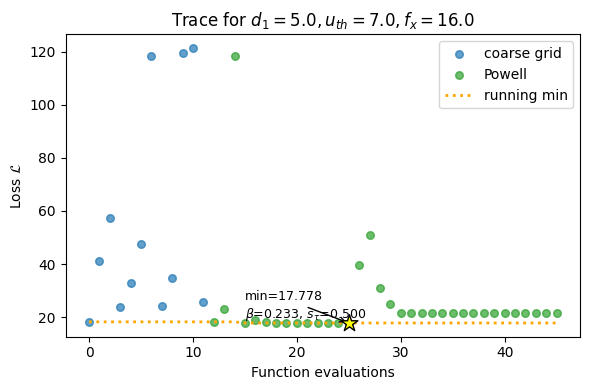

In [19]:
import matplotlib.pyplot as plt

df = df_best.copy()
df["running_min"] = df["loss"].cummin()

plt.figure(figsize=(6,4))

g = df[df["stage"] == "grid"]
p = df[df["stage"] == "powell"]

plt.scatter(g["eval_idx"], g["loss"],
            c="tab:blue", s=30, alpha=0.7, label="coarse grid")

plt.scatter(p["eval_idx"], p["loss"],
            c="tab:green", s=30, alpha=0.7, label="Powell")

plt.plot(df["eval_idx"], df["running_min"],
         color="orange", linewidth=2, label="running min",linestyle=":")

# best_idx = df["loss"].idxmin()
# best = df.loc[best_idx]

#  loss  eval_idx 
df_sorted = df.sort_values(['loss', 'eval_idx'],
                           ascending=[True, False])

# loss  eval_idx 
best = df_sorted.iloc[0]
best_idx = best.name   #  index


plt.scatter(best["eval_idx"], best["loss"],
            marker="*", s=160, edgecolor="k", facecolor="yellow", zorder=5)

txt = (f"min={best['loss']:.3f}\n"
       f"$\\beta$={best['beta']:.3f}, $s_\\tau$={best['s_tau']:.3f}")
plt.annotate(
    txt,
    xy=(best["eval_idx"], best["loss"]),
    xytext=(best["eval_idx"]-10, best["loss"]+2),
    arrowprops=dict(arrowstyle='->', lw=1),
    fontsize=9
)

plt.xlabel("Function evaluations")
plt.ylabel(r"Loss $\mathcal{L}$")
plt.title(rf"Trace for $d_1={d1}, u_{{th}}={uth}, f_x={fx}$")
plt.legend()
plt.tight_layout()
plt.savefig("fig/trace_for_d1="+str(d1)+",uth="+str(uth)+",fx="+str(fx)+".png", bbox_inches="tight", dpi=600)
plt.show()


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_optimization_path_paper(
    df_trace,
    d1,
    uth,
    fx,
    outpath=None,
    figsize=(6.2, 4.8),
    annotate_final=True,
):
    """
    
      - coarse grid:  loss
      - Powell path:  + 
      -  coarse-grid best  final optimum
    """

    df = df_trace.copy().reset_index(drop=True)

    g = df[df["stage"] == "grid"].copy()
    p = df[df["stage"] == "powell"].copy()

    if len(g) == 0:
        raise ValueError("df_trace  stage='grid' ")
    if len(p) == 0:
        raise ValueError("df_trace  stage='powell' ")

    # coarse-grid 
    g_best_idx = g["loss"].idxmin()
    g_best = df.loc[g_best_idx]

    # final optimum
    df_sorted = df.sort_values(["loss", "eval_idx"], ascending=[True, False])
    best = df_sorted.iloc[0]

    fig, ax = plt.subplots(figsize=figsize)

    # -------------------------
    # 1) coarse grid: colored scatter
    # -------------------------
    sc = ax.scatter(
        g["beta"], g["s_tau"],
        c=g["loss"],
        s=90,
        cmap="viridis",
        edgecolor="k",
        linewidth=0.5,
        zorder=2,
        label="Coarse grid"
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r"Loss $\mathcal{L}$")

    # -------------------------
    # 2) Powell path
    # -------------------------
    ax.plot(
        p["beta"], p["s_tau"],
        "-",
        lw=1.8,
        alpha=0.9,
        zorder=3,
        label="Powell path"
    )

    ax.scatter(
        p["beta"], p["s_tau"],
        s=28,
        zorder=4
    )

    # -------------------------
    # 3) Mark coarse-grid best
    # -------------------------
    ax.scatter(
        g_best["beta"], g_best["s_tau"],
        marker="s",
        s=110,
        facecolor="white",
        edgecolor="k",
        linewidth=1.2,
        zorder=5,
        label="Best coarse-grid point"
    )

    # -------------------------
    # 4) Mark final optimum
    # -------------------------
    ax.scatter(
        best["beta"], best["s_tau"],
        marker="*",
        s=220,
        facecolor="gold",
        edgecolor="k",
        linewidth=1.0,
        zorder=6,
        label="Final optimum"
    )

    if annotate_final:
        txt = (
            rf"$\beta={best['beta']:.3f}$" "\n"
            rf"$s_\tau={best['s_tau']:.3f}$" "\n"
            rf"$\mathcal{{L}}={best['loss']:.3f}$"
        )
        ax.annotate(
            txt,
            xy=(best["beta"], best["s_tau"]),
            xytext=(best["beta"] + 0.05, best["s_tau"] + 0.08),
            textcoords="data",
            arrowprops=dict(arrowstyle="->", lw=1.0),
            fontsize=9,
            ha="left",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
        )

    # -------------------------
    # 5) axis / title / style
    # -------------------------
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$s_\tau$")
    ax.set_title(rf"$d_1={d1},\ u_{{th}}={uth},\ f_x={fx}$")

    ax.set_xlim(df["beta"].min() - 0.03, df["beta"].max() + 0.05)
    ax.set_ylim(df["s_tau"].min() - 0.05, df["s_tau"].max() + 0.08)

    ax.legend(frameon=True, fontsize=9, loc="best")
    ax.grid(True, alpha=0.2, linewidth=0.6)

    plt.tight_layout()

    if outpath is not None:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        plt.savefig(outpath, dpi=600, bbox_inches="tight")

    plt.show()

    return fig, ax

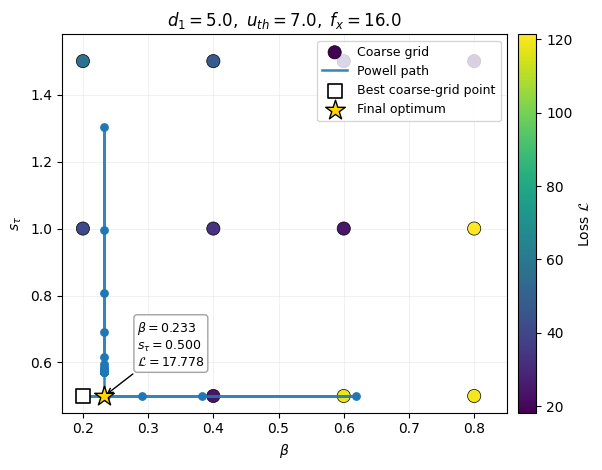

In [21]:
fig, ax = plot_optimization_path_paper(
    df_trace=df_best,
    d1=5.0,
    uth=7.0,
    fx=16.0,
    outpath="fig/opt_path_d1_5p0_uth_7p0_fx_16p0.png",
)

Global best triple (by grid_loss):
damp1_days          5.0
u_thres             7.0
flux_extra         16.0
grid_loss     18.204065
Name: 33, dtype: object


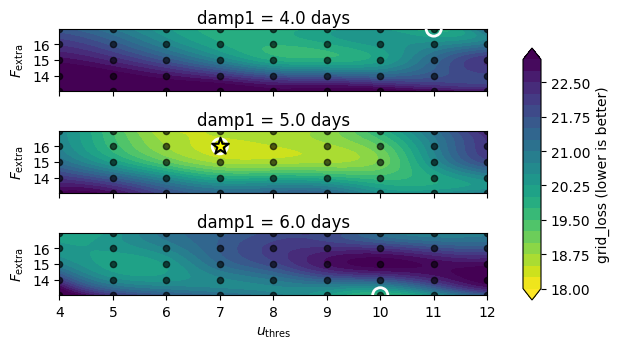

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline

from scipy.interpolate import RegularGridInterpolator

from scipy.ndimage import gaussian_filter

# ===== 1.  &  =====
df_tri = pd.read_csv("/nas/smliu01/graybox_results/graybox_fullgrid_new_epflux.csv")
df_tri = df_tri[pd.to_numeric(df_tri["grid_loss"], errors="coerce").notna()].copy()
df_tri["grid_loss"] = df_tri["grid_loss"].astype(float)
df_tri = df_tri.reset_index(drop=True)

#  best grid_loss
min_grid = df_tri["grid_loss"].min()
eps = 1e-8
cands = df_tri[np.abs(df_tri["grid_loss"] - min_grid) < eps]
best_tri = cands.iloc[0]

print("Global best triple (by grid_loss):")
print(best_tri[["damp1_days","u_thres","flux_extra","grid_loss"]])

# ===== 2.  contour damp1  panel =====
damps = sorted(df_tri["damp1_days"].unique())
n_d   = len(damps)

#  * 1.2
fig, axes = plt.subplots(
    n_d, 1,
    figsize=(6.0, 1.2 * n_d),
    sharex=True, sharey=True
)

if n_d == 1:
    axes = [axes]
else:
    axes = np.array(axes).ravel()

vmin = 18 #df_tri["grid_loss"].min()
vmax = 23 #df_tri["grid_loss"].max()

levels = np.linspace(vmin, vmax, 21)

cs = None

for ax, d1 in zip(axes, damps):
    sub = df_tri[df_tri["damp1_days"] == d1].copy()

    # 
    uth_vals = np.sort(sub["u_thres"].unique())
    fx_vals  = np.sort(sub["flux_extra"].unique())

    # pivot  (fx, uth)  Z
    pivot = sub.pivot_table(
        index="flux_extra", columns="u_thres", values="grid_loss"
    ).reindex(index=fx_vals, columns=uth_vals)
    Z = pivot.values

    # 
    kx = 1 #min(3, len(fx_vals)  - 1)
    ky = 1 #min(3, len(uth_vals) - 1)
    # interp = RectBivariateSpline(fx_vals, uth_vals, Z, kx=kx, ky=ky)

    Z_smooth = gaussian_filter(Z, sigma=0.6, mode="nearest")

    interp = RectBivariateSpline(
        fx_vals, uth_vals, Z_smooth,
        kx=3, ky=3
    )

    uth_fine = np.linspace(uth_vals.min(), uth_vals.max(), 200)
    fx_fine  = np.linspace(fx_vals.min(),  fx_vals.max(),  200)
    U_FINE, F_FINE = np.meshgrid(uth_fine, fx_fine)
    Z_FINE = interp(fx_fine, uth_fine)







    # contourf vmin/vmax
    cs = ax.contourf(
        U_FINE, F_FINE, Z_FINE,
        levels=levels, cmap="viridis_r",
        vmin=vmin, vmax=vmax,extend="both"
    )

    # 
    ax.scatter(sub["u_thres"], sub["flux_extra"],
               s=20, c="k", alpha=0.6)

    # 
    best_local = sub.loc[sub["grid_loss"].idxmin()]
    ax.scatter(
        best_local["u_thres"], best_local["flux_extra"],
        s=120, facecolor="none", edgecolor="white",
        linewidth=2.0, zorder=3
    )

    #  damp1 
    if np.isclose(best_tri["damp1_days"], d1):
        ax.scatter(
            best_tri["u_thres"], best_tri["flux_extra"],
            s=160, marker="*",
            facecolor="yellow", edgecolor="k",
            linewidth=1.5, zorder=4
        )

    ax.set_title(f"damp1 = {d1:.1f} days", pad=4)
    ax.set_ylabel(r"$F_{\mathrm{extra}}$")

    #  14, 15, 16  y tick
    ax.set_yticks([14.0, 15.0, 16.0])

axes[-1].set_xlabel(r"$u_{\mathrm{thres}}$")

# ===== 3.  colorbar =====
# 
fig.tight_layout(rect=[0.0, 0.0, 0.86, 1.0])

#  colorbar 
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
cbar = fig.colorbar(cs, cax=cax)
cbar.set_label("grid_loss (lower is better)")

# fig.suptitle(
#     "grid_loss landscape over discrete triples\n(contours from interpolated grid)",
#     y=0.99
# )

plt.savefig("fig/grid_loss_landscape.png", bbox_inches="tight", dpi=600)
plt.show()


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter

# ============================================================
# 1) optimization path
# ============================================================
def draw_optimization_path_on_ax(
    df_trace,
    d1,
    uth,
    fx,
    ax,
    cax=None,
    annotate_final=True,
):
    df = df_trace.copy().reset_index(drop=True)

    g = df[df["stage"] == "grid"].copy()
    p = df[df["stage"] == "powell"].copy()

    if len(g) == 0:
        raise ValueError("df_trace  stage='grid' ")
    if len(p) == 0:
        raise ValueError("df_trace  stage='powell' ")

    g_best_idx = g["loss"].idxmin()
    g_best = df.loc[g_best_idx]

    df_sorted = df.sort_values(["loss", "eval_idx"], ascending=[True, False])
    best = df_sorted.iloc[0]

    sc = ax.scatter(
        g["beta"], g["s_tau"],
        c=g["loss"],
        s=90,
        cmap="viridis",
        edgecolor="k",
        linewidth=0.5,
        zorder=2,
        label="Coarse grid"
    )

    ax.plot(
        p["beta"], p["s_tau"],
        "-",
        lw=1.8,
        alpha=0.9,
        zorder=3,
        label="Powell path"
    )

    ax.scatter(
        p["beta"], p["s_tau"],
        s=28,
        zorder=4
    )

    ax.scatter(
        g_best["beta"], g_best["s_tau"],
        marker="s",
        s=110,
        facecolor="white",
        edgecolor="k",
        linewidth=1.2,
        zorder=5,
        label="Best coarse-grid point"
    )

    ax.scatter(
        best["beta"], best["s_tau"],
        marker="*",
        s=220,
        facecolor="gold",
        edgecolor="k",
        linewidth=1.0,
        zorder=6,
        label="Final optimum"
    )

    if annotate_final:
        txt = (
            rf"$\beta={best['beta']:.3f}$" "\n"
            rf"$s_\tau={best['s_tau']:.3f}$" "\n"
            rf"$\mathcal{{L}}={best['loss']:.3f}$"
        )
        ax.annotate(
            txt,
            xy=(best["beta"], best["s_tau"]),
            xytext=(best["beta"] + 0.05, best["s_tau"] + 0.08),
            textcoords="data",
            arrowprops=dict(arrowstyle="->", lw=1.0),
            fontsize=9,
            ha="left",
            va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.6", alpha=0.9),
        )

    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$s_\tau$")
    ax.set_title(rf"Optimization path: $d_1={d1},\ u^*={uth},\ \Delta u={fx}$")
    ax.set_xlim(df["beta"].min() - 0.03, df["beta"].max() + 0.05)
    ax.set_ylim(df["s_tau"].min() - 0.05, df["s_tau"].max() + 0.08)
    ax.legend(frameon=True, fontsize=8.5, loc="best")
    ax.grid(True, alpha=0.2, linewidth=0.6)

    if cax is not None:
        cbar = plt.colorbar(sc, cax=cax)
        cbar.set_label(r"Loss $\mathcal{L}$")

    return ax


# ============================================================
# 2) grid_loss landscape
# ============================================================
def draw_grid_loss_landscape_on_axes(
    df_tri,
    axes,
    cax=None,
    vmin=18,
    vmax=23,
    sigma=0.6,
):
    df_tri = df_tri.copy()
    df_tri = df_tri[pd.to_numeric(df_tri["grid_loss"], errors="coerce").notna()].copy()
    df_tri["grid_loss"] = df_tri["grid_loss"].astype(float)
    df_tri = df_tri.reset_index(drop=True)

    min_grid = df_tri["grid_loss"].min()
    eps = 1e-8
    cands = df_tri[np.abs(df_tri["grid_loss"] - min_grid) < eps]
    best_tri = cands.iloc[0]

    damps = sorted(df_tri["damp1_days"].unique())
    if len(axes) != len(damps):
        raise ValueError(f"axes  {len(axes)}  damp1  {len(damps)} ")

    levels = np.linspace(vmin, vmax, 21)
    cs = None

    for i, (ax, d1) in enumerate(zip(axes, damps)):
        sub = df_tri[df_tri["damp1_days"] == d1].copy()

        uth_vals = np.sort(sub["u_thres"].unique())
        fx_vals  = np.sort(sub["flux_extra"].unique())

        pivot = sub.pivot_table(
            index="flux_extra", columns="u_thres", values="grid_loss"
        ).reindex(index=fx_vals, columns=uth_vals)

        Z = pivot.values
        Z_smooth = gaussian_filter(Z, sigma=sigma, mode="nearest")

        interp = RectBivariateSpline(
            fx_vals, uth_vals, Z_smooth,
            kx=3, ky=3
        )

        uth_fine = np.linspace(uth_vals.min(), uth_vals.max(), 200)
        fx_fine  = np.linspace(fx_vals.min(),  fx_vals.max(),  200)
        U_FINE, F_FINE = np.meshgrid(uth_fine, fx_fine)
        Z_FINE = interp(fx_fine, uth_fine)

        cs = ax.contourf(
            U_FINE, F_FINE, Z_FINE,
            levels=levels, cmap="viridis_r",
            vmin=vmin, vmax=vmax, extend="both"
        )

        ax.scatter(
            sub["u_thres"], sub["flux_extra"],
            s=20, c="k", alpha=0.6
        )

        best_local = sub.loc[sub["grid_loss"].idxmin()]
        ax.scatter(
            best_local["u_thres"], best_local["flux_extra"],
            s=120, facecolor="none", edgecolor="white",
            linewidth=2.0, zorder=3
        )

        if np.isclose(best_tri["damp1_days"], d1):
            ax.scatter(
                best_tri["u_thres"], best_tri["flux_extra"],
                s=160, marker="*",
                facecolor="yellow", edgecolor="k",
                linewidth=1.5, zorder=4
            )

        ax.set_title(f"$d_1={d1:.1f}$ days", pad=4)
        ax.set_ylabel(r"$\Delta u$")
        ax.set_yticks([14.0, 15.0, 16.0])

        # ----  1 panel  x ticks / labels ----
        if i < len(axes) - 1:
            ax.tick_params(axis="x", which="both",
                           bottom=False, top=False, labelbottom=False)

    axes[-1].set_xlabel(r"$u^*$")

    if cax is not None and cs is not None:
        cbar = plt.colorbar(cs, cax=cax)
        cbar.set_label("grid_loss")

    return axes


# ============================================================
# 3)  landscape optimization path
# ============================================================
def plot_combined_figure(
    df_trace,
    df_tri,
    d1_path,
    uth_path,
    fx_path,
    outpath=None,
    figsize=(12.0, 4.0),
    vmin=18,
    vmax=23,
):
    damps = sorted(df_tri["damp1_days"].dropna().unique())
    n_d = len(damps)

    fig = plt.figure(figsize=figsize)

    # ----    ----
    outer = fig.add_gridspec(
        1, 2,
        width_ratios=[1.2, 1.1],
        wspace=0.5
    )

    # ----  +  colorbar ----
    left_group = outer[0, 0].subgridspec(
        1, 2,
        width_ratios=[1.0, 0.04],
        wspace=0.04   #  2 colorbar 
    )

    left_panels = left_group[0, 0].subgridspec(n_d, 1, hspace=0.30)
    left_axes = [fig.add_subplot(left_panels[i, 0]) for i in range(n_d)]
    left_cax = fig.add_subplot(left_group[0, 1])

    draw_grid_loss_landscape_on_axes(
        df_tri=df_tri,
        axes=left_axes,
        cax=left_cax,
        vmin=vmin,
        vmax=vmax,
        sigma=0.6,
    )

    # ----  +  colorbar ----
    right_group = outer[0, 1].subgridspec(
        1, 2,
        width_ratios=[1.0, 0.05],
        wspace=0.35
    )

    right_ax = fig.add_subplot(right_group[0, 0])
    right_cax = fig.add_subplot(right_group[0, 1])

    draw_optimization_path_on_ax(
        df_trace=df_trace,
        d1=d1_path,
        uth=uth_path,
        fx=fx_path,
        ax=right_ax,
        cax=right_cax,
        annotate_final=True,
    )

    # panel labels
    left_axes[0].text(
        -0.22, 1.12, "(a)",
        transform=left_axes[0].transAxes,
        fontsize=15,  va="top"
    )
    right_ax.text(
        -0.35, 1.08, "(b)",
        transform=right_ax.transAxes,
        fontsize=15,  va="top"
    )

    #fig.suptitle("Gray-box optimization summary", y=0.995, fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    if outpath is not None:
        os.makedirs(os.path.dirname(outpath), exist_ok=True)
        fig.savefig(outpath, dpi=600, bbox_inches="tight")

    plt.show()
    return fig

/tmp/ipykernel_995592/896477674.py:291: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.98])


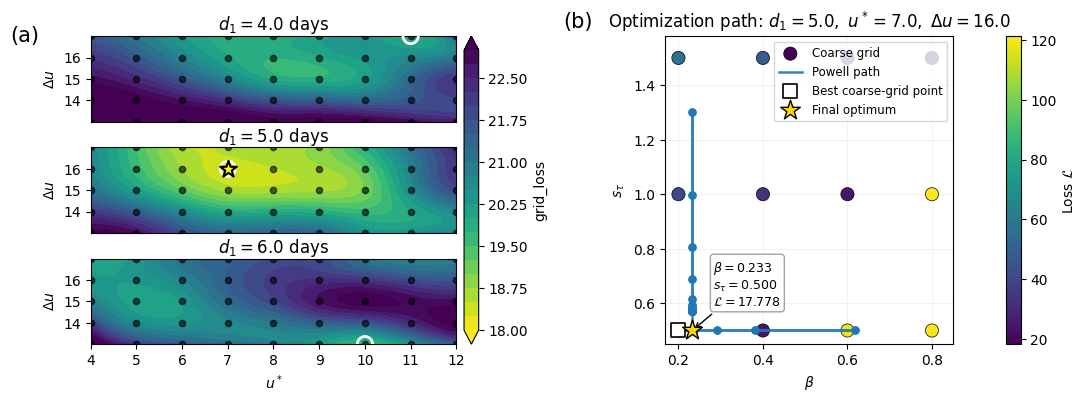

In [24]:
fig = plot_combined_figure(
    df_trace=df_best,
    df_tri=df_tri,
    d1_path=5.0,
    uth_path=7.0,
    fx_path=16.0,
    outpath="fig/combined_landscape_and_path_v2.png",
    figsize=(12.0, 4.0),
    vmin=18,
    vmax=23,
)

In [46]:
import os
import csv
import time
import warnings
import subprocess
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from netCDF4 import Dataset
from scipy.stats import wasserstein_distance, spearmanr
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings("ignore", message=".*converting a masked element to nan.*")

# ============================================================
# user settings
# ============================================================
WORK_DIR = "/nas/smliu01/graybox_stage2"
YEARS = 42

OUT_U_BASENAME = "uout"   # var = ubar
OUT_A_BASENAME = "aout"   # var = fawa
OUT_UR_BASENAME = "urout" # var = uref

KMAX_MODEL = 501
JSD_BINS = 32

# ------------------------------------------------------------
# fixed stage-1 optimum ()
# 
#   SAVE_CSV
#   df_best
#   load_best_from_csv
# ------------------------------------------------------------
best_grid = load_best_from_csv(SAVE_CSV, metric="grid_loss")

DAMP1_FIX     = float(best_grid["damp1_days"])
UTHRES_FIX    = float(best_grid["u_thres"])
FLUXEXTRA_FIX = float(best_grid["flux_extra"])

print("Using best_grid triple:")
print(DAMP1_FIX, UTHRES_FIX, FLUXEXTRA_FIX)

best_trace = df_best.sort_values(["loss", "eval_idx"], ascending=[True, False]).iloc[0]

BETA_FIX = float(best_trace["beta"])
STAU_FIX = float(best_trace["s_tau"])
BEST_LOSS_FIX = float(best_trace["loss"])

print(BETA_FIX, STAU_FIX)

# ------------------------------------------------------------
# stage-2 discrete grid
# ------------------------------------------------------------
ALPHA_LIST  = [0.40, 0.45, 0.50, 0.55, 0.60]
CONST1_LIST = [1.8e-3, 2.0e-3, 2.2e-3, 2.4e-3, 2.6e-3]
PPOW_LIST   = [2.0, 2.5, 3.0, 3.5, 4.0]
AEXP_LIST   = [0.20, 0.225, 0.25, 0.275, 0.30]

# ------------------------------------------------------------
# levels
# ------------------------------------------------------------
ERA_LEVELS = {
    "60hPa": 39,
    "10hPa": 64,
    "3hPa": 81,
}

MODEL_LEVELS = {
    "60hPa": 48,
    "10hPa": 110,
    "3hPa": 153,
}

# ------------------------------------------------------------
# weights
# ------------------------------------------------------------
LEVEL_WEIGHTS = {
    "60hPa": 0.25,
    "10hPa": 0.50,
    "3hPa": 0.25,
}

VAR_WEIGHTS = {
    "a": 1/3,   # fawa
    "u": 1/3,   # ubar
    "r": 1/3,   # uref
}

DIST_FRAC_STAGE2 = 0.35

ERA_MONTHLY_SSW = np.array([0., 5., 7., 9., 1., 0.], dtype=float)  # Nov, Dec, Jan, Feb, Mar, Apr
MONTH_ORDER = ["11", "12", "01", "02", "03", "04"]

SSW_DMAX_REF = 992


# ============================================================
# ERA loading helpers
# ============================================================
def build_vertical_coordinates():
    zdim = 501
    height = np.zeros(97)
    plev = np.zeros(97)
    h1d = np.zeros(zdim)

    dz = 500.0
    hh = 7000.0
    dz1d = 100000.0 / (zdim - 1)

    for k in range(97):
        height[k] = k * dz
        plev[k] = 1000.0 * np.exp(-height[k] / hh)

    for k in range(zdim):
        h1d[k] = dz1d * k + 10000.0

    return height, plev, h1d


def Oct_to_May(vv):
    vbar = np.zeros((97, 42, 992))
    month = [9, 10, 11, 0, 1, 2, 3, 4]

    for z in range(97):
        i = 0
        while i < 42:
            m = 0
            k = 0
            while m < 8:
                j = 0
                while j < 124:
                    if m < 3:
                        if vv[z, j, month[m], i] != 0:
                            vbar[z, i, k] = vv[z, j, month[m], i]
                            k += 1
                    else:
                        if vv[z, j, month[m], i + 1] != 0:
                            vbar[z, i, k] = vv[z, j, month[m], i + 1]
                            k += 1
                    j += 1
                m += 1
            vbar[vbar == 0] = np.nan
            i += 1

    return vbar


def Nov_to_Mar(vv):
    vbar = np.zeros((97, 42, 604))
    month = [10, 11, 0, 1, 2]

    for z in range(97):
        i = 0
        while i < 42:
            m = 0
            k = 0
            while m < 5:
                j = 0
                while j < 124:
                    if m < 2:
                        if vv[z, j, month[m], i] != 0:
                            vbar[z, i, k] = vv[z, j, month[m], i]
                            k += 1
                    else:
                        if vv[z, j, month[m], i + 1] != 0:
                            vbar[z, i, k] = vv[z, j, month[m], i + 1]
                            k += 1
                    j += 1
                m += 1
            vbar[vbar == 0] = np.nan
            i += 1

    return vbar


def load_era_data():
    filename1 = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/ana60n.nc'
    ncin1 = Dataset(filename1, 'r', format='NETCDF4')
    epz = np.array(ncin1.variables['epz'])
    fawa = np.array(ncin1.variables['fawa'])
    ubar = np.array(ncin1.variables['ubar'])
    uref = np.array(ncin1.variables['uref'])
    ncin1.close()

    file = '/nas/winds-home/smliu01/3.era-5,ssw_1.2022/sea60n.nc'
    ncin1 = Dataset(file, 'r', format='NETCDF4')
    fawa_sea = np.array(ncin1.variables['fawa'])
    ubar_sea = np.array(ncin1.variables['ubar'])
    uref_sea = np.array(ncin1.variables['uref'])
    epz_sea = np.array(ncin1.variables['epz'])
    ncin1.close()

    fawa_sea_n = np.zeros((97, 124, 12, 43))
    ubar_sea_n = np.zeros((97, 124, 12, 43))
    uref_sea_n = np.zeros((97, 124, 12, 43))
    epz_sea_n = np.zeros((97, 124, 12, 43))

    for i in range(43):
        fawa_sea_n[:, :, :, i] = fawa_sea[:, :, :]
        ubar_sea_n[:, :, :, i] = ubar_sea[:, :, :]
        uref_sea_n[:, :, :, i] = uref_sea[:, :, :]
        epz_sea_n[:, :, :, i] = epz_sea[:, :, :]

    uref_eachyr = Nov_to_Mar(uref)
    ubar_eachyr = Nov_to_Mar(ubar)
    fawa_eachyr = Nov_to_Mar(fawa)
    epz_eachyr = Nov_to_Mar(epz)

    uref_sea_novmar = np.mean(Nov_to_Mar(uref_sea_n), axis=1)
    ubar_sea_novmar = np.mean(Nov_to_Mar(ubar_sea_n), axis=1)
    fawa_sea_novmar = np.mean(Nov_to_Mar(fawa_sea_n), axis=1)
    epz_sea_novmar = np.mean(Nov_to_Mar(epz_sea_n), axis=1)

    return {
        "uref_eachyr": uref_eachyr,
        "ubar_eachyr": ubar_eachyr,
        "fawa_eachyr": fawa_eachyr,
        "epz_eachyr": epz_eachyr,
        "uref_sea_novmar": uref_sea_novmar,
        "ubar_sea_novmar": ubar_sea_novmar,
        "fawa_sea_novmar": fawa_sea_novmar,
        "epz_sea_novmar": epz_sea_novmar,
    }


# ============================================================
# model I/O helpers
# ============================================================
def tag_from_params_stage2(beta, s_tau, damp1_days, u_thres, flux_extra,
                           alpha, const1, ppow, aexp):
    #  stage1/run.sh 
    b  = f"{beta:.2f}".replace(".", "p")
    s  = f"{s_tau:.1f}".replace(".", "p")
    d1 = f"{int(round(damp1_days))}"
    ut = f"{u_thres:.1f}".replace(".", "p")
    fx = f"{flux_extra:.1f}".replace(".", "p")

    a  = f"{alpha:.2f}".replace(".", "p")
    c1 = f"{const1:.3e}".replace(".", "p").replace("+", "").replace("-", "m")
    pp = f"{ppow:.1f}".replace(".", "p")
    ae = f"{aexp:.3f}".replace(".", "p")

    return f"b{b}s{s}_d{d1}u{ut}f{fx}_a{a}_c{c1}_p{pp}_e{ae}"


def _tag_paths(workdir, outtag):
    p_u  = Path(workdir) / f"{OUT_U_BASENAME}_{outtag}.nc"
    p_a  = Path(workdir) / f"{OUT_A_BASENAME}_{outtag}.nc"
    p_ur = Path(workdir) / f"{OUT_UR_BASENAME}_{outtag}.nc"
    return p_u, p_a, p_ur


def run_once_stage2(beta, s_tau, damp1_days, u_thres, flux_extra,
                    alpha, const1, ppow, aexp,
                    outtag=None, workdir=WORK_DIR, timeout_sec=43200, force=False):
    if outtag is None:
        outtag = tag_from_params_stage2(
            beta, s_tau, damp1_days, u_thres, flux_extra,
            alpha, const1, ppow, aexp
        )

    p_u_tag, p_a_tag, p_ur_tag = _tag_paths(workdir, outtag)

    if (not force) and p_u_tag.exists() and p_a_tag.exists() and p_ur_tag.exists():
        return str(p_u_tag), str(p_a_tag), str(p_ur_tag)

    cmd = (
        f'./run.sh {beta} {s_tau} {damp1_days} {u_thres} {flux_extra} '
        f'{alpha} {const1} {ppow} {aexp} {outtag}'
    )

    res = subprocess.run(
        ["bash", "-lc", cmd],
        cwd=workdir,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        timeout=timeout_sec,
    )

    if res.returncode != 0:
        print("=== STDOUT ===\n", res.stdout)
        print("=== STDERR ===\n", res.stderr)
        raise RuntimeError(f"Stage2 model run failed ({outtag})")

    if p_u_tag.exists() and p_a_tag.exists() and p_ur_tag.exists():
        return str(p_u_tag), str(p_a_tag), str(p_ur_tag)

    raise FileNotFoundError(f"Missing outputs after run: {outtag}")


def _read_time_height(nc_path, varname, years):
    with Dataset(nc_path, "r") as ds:
        v = ds.variables[varname][:]
        dims = getattr(ds.variables[varname], "dimensions", None)

    if v.ndim != 2:
        raise ValueError(f"{nc_path}:{varname} ndim={v.ndim}, expect 2")

    n0, n1 = v.shape

    if n0 % years == 0 and n1 % years != 0:
        arr = v
        time_len, kmax_found = n0, n1
    elif n1 % years == 0 and n0 % years != 0:
        arr = v.T
        time_len, kmax_found = n1, n0
    else:
        if n1 == KMAX_MODEL and n0 % years == 0:
            arr = v
            time_len, kmax_found = n0, n1
        elif n0 == KMAX_MODEL and n1 % years == 0:
            arr = v.T
            time_len, kmax_found = n1, n0
        else:
            raise ValueError(
                f"Cannot infer dims {nc_path}:{varname}, shape={v.shape}, dims={dims}"
            )

    n_per_year = time_len // years
    return arr, n_per_year, kmax_found


def load_model_multilevel(u_nc, a_nc, ur_nc, years=YEARS, model_levels=MODEL_LEVELS):
    u_arr, n_per_year_u, kmax_u = _read_time_height(u_nc, "ubar", years)
    a_arr, n_per_year_a, kmax_a = _read_time_height(a_nc, "fawa", years)
    r_arr, n_per_year_r, kmax_r = _read_time_height(ur_nc, "uref", years)

    u_arr = u_arr.reshape(years, n_per_year_u, kmax_u)
    a_arr = a_arr.reshape(years, n_per_year_a, kmax_a)
    r_arr = r_arr.reshape(years, n_per_year_r, kmax_r)

    t_end = int(n_per_year_u * 7 / 8)   # Oct-Apr

    out = {}
    for lev_name, k in model_levels.items():
        out[lev_name] = {
            "u_clim": u_arr.mean(axis=0)[:t_end, k].astype(np.float64),
            "a_clim": a_arr.mean(axis=0)[:t_end, k].astype(np.float64),
            "r_clim": r_arr.mean(axis=0)[:t_end, k].astype(np.float64),

            "u_all": u_arr[:, :t_end, k].ravel().astype(np.float64),
            "a_all": a_arr[:, :t_end, k].ravel().astype(np.float64),
            "r_all": r_arr[:, :t_end, k].ravel().astype(np.float64),
        }

    return out, t_end


def load_model_u10_raw_for_ssw(u_nc, years=YEARS, k10=MODEL_LEVELS["10hPa"]):
    """
     10 hPa ubar t_end=7/8 
    :
      u10_2d_raw : shape = (years, n_per_year_raw)
      n_per_year_raw
    """
    u_arr, n_per_year_u, kmax_u = _read_time_height(u_nc, "ubar", years)
    u_arr = u_arr.reshape(years, n_per_year_u, kmax_u)

    u10_2d_raw = u_arr[:, :, k10].astype(np.float64)
    return u10_2d_raw, n_per_year_u


def build_era_multilevel_targets(ubar_eachyr, fawa_eachyr, uref_eachyr, era_levels=ERA_LEVELS):
    t_end = int(604 * 7 / 8)

    out = {}
    for lev_name, k in era_levels.items():
        out[lev_name] = {
            "u_clim": ubar_eachyr[k, :, :t_end].mean(axis=0).astype(np.float64),
            "a_clim": fawa_eachyr[k, :, :t_end].mean(axis=0).astype(np.float64),
            "r_clim": uref_eachyr[k, :, :t_end].mean(axis=0).astype(np.float64),

            "u_all": ubar_eachyr[k, :, :t_end].ravel().astype(np.float64),
            "a_all": fawa_eachyr[k, :, :t_end].ravel().astype(np.float64),
            "r_all": uref_eachyr[k, :, :t_end].ravel().astype(np.float64),
        }
    return out


# ============================================================
# loss helpers
# ============================================================
def interp_to(x, n_target):
    x0 = np.linspace(0.0, 1.0, len(x), endpoint=False)
    x1 = np.linspace(0.0, 1.0, n_target, endpoint=False)
    return np.interp(x1, x0, x)


def _zscore(x):
    x = np.asarray(x, dtype=np.float64)
    m = x.mean()
    s = x.std()
    return (x - m) / s if s > 0 else x * 0.0


def distribution_loss(model_vals, era_vals, bins=JSD_BINS):
    xm = _zscore(np.ravel(model_vals))
    xe = _zscore(np.ravel(era_vals))

    emd = float(wasserstein_distance(xm, xe))

    lo = float(min(xm.min(), xe.min()))
    hi = float(max(xm.max(), xe.max()))

    if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo == hi):
        jsd = 0.0
    else:
        hist_m, edges = np.histogram(xm, bins=bins, range=(lo, hi), density=True)
        hist_e, _ = np.histogram(xe, bins=edges, density=True)
        eps = 1e-12
        pm = hist_m + eps
        pe = hist_e + eps
        pm = pm / pm.sum()
        pe = pe / pe.sum()
        jsd = float(jensenshannon(pm, pe))

    return emd + jsd


def multilevel_loss(model_dict, era_dict, dist_frac=DIST_FRAC_STAGE2):
    total = 0.0
    detail = {}

    for lev in LEVEL_WEIGHTS:
        lev_loss = 0.0
        lev_detail = {}

        for var in ["a", "u", "r"]:
            m_clim = model_dict[lev][f"{var}_clim"]
            e_clim = era_dict[lev][f"{var}_clim"]
            m_all = model_dict[lev][f"{var}_all"]
            e_all = era_dict[lev][f"{var}_all"]

            if len(e_clim) != len(m_clim):
                e_clim_use = interp_to(e_clim, len(m_clim))
            else:
                e_clim_use = e_clim

            rmse = float(np.sqrt(np.mean((m_clim - e_clim_use) ** 2)))
            dist = float(distribution_loss(m_all, e_all))
            comp = (1.0 - dist_frac) * rmse + dist_frac * 100.0 * dist

            lev_loss += VAR_WEIGHTS[var] * comp
            lev_detail[var] = {"rmse": rmse, "dist": dist, "comp": comp}

        total += LEVEL_WEIGHTS[lev] * lev_loss
        detail[lev] = lev_detail

    return total, detail


# ============================================================
# SSW helpers ( stage1 )
# ============================================================
def model_u10_to_era5_like_inputs(u10_2d_raw, start_year=1979):
    """
     10 hPa  ERA5-like 
    ubp:  shape = (years, 992)
    date: shape = (years, 992),  'YYYY/MM/DD/HH'
    """
    u10_2d_raw = np.asarray(u10_2d_raw, dtype=float)
    years, steps_per_year_src = u10_2d_raw.shape

    tgt_len = 992
    src_x = np.arange(steps_per_year_src, dtype=float)
    tgt_x = np.linspace(0, steps_per_year_src - 1, tgt_len)

    ubp = np.empty((years, tgt_len), dtype=float)
    for y in range(years):
        ubp[y] = np.interp(tgt_x, src_x, u10_2d_raw[y])

    time4 = ['00', '06', '12', '18']
    months = ['10', '11', '12', '01', '02', '03', '04', '05']
    days31 = [f"{d:02d}" for d in range(1, 32)]

    date = [[None] * tgt_len for _ in range(years)]
    for y in range(years):
        k = 0
        for mi, mm in enumerate(months):
            year_label = (start_year + y) if mi < 3 else (start_year + y + 1)
            for dd in days31:
                for hh in time4:
                    date[y][k] = f"{year_label}/{mm}/{dd}/{hh}"
                    k += 1

    return ubp, np.array(date, dtype=object)


def count_ssw_events_from_u10(
    u_all_flat,
    n_per_year,
    years,
    dmax_ref=SSW_DMAX_REF,
    min_gap_days=10,
    min_gap_onset_days=20,
    min_duration_days=2,
    use_djf_only=False,
    return_debug=False,
    date_2d=None,
    enforce_march10_cutoff=True,
    exclude_onset_indices=None,
):
    u_all_flat = np.asarray(u_all_flat, dtype=float)
    assert u_all_flat.size == years * n_per_year, \
        f"u_all_flat ={u_all_flat.size},  years*n_per_year={years*n_per_year}"

    u_2d = u_all_flat.reshape(years, n_per_year)

    scale = n_per_year / float(dmax_ref)
    steps_per_day = 4.0 * scale

    min_gap_steps       = max(1, int(round(min_gap_days * steps_per_day)))
    min_gap_onset_steps = max(1, int(round(min_gap_onset_days * steps_per_day)))
    min_duration_steps  = max(1, int(round(min_duration_days * steps_per_day)))

    djf_start = None
    djf_end   = None

    if use_djf_only:
        djf_start_frac = 2.0 / 7.0
        djf_end_frac   = 5.0 / 7.0

        djf_start = int(round(djf_start_frac * n_per_year))
        djf_end   = int(round(djf_end_frac   * n_per_year))

        djf_mask = np.zeros_like(u_2d, dtype=bool)
        djf_mask[:, djf_start:djf_end] = True

        neg_2d   = (u_2d < 0.0) & djf_mask
        neg_flat = neg_2d.ravel()
    else:
        neg_flat = (u_2d < 0.0).ravel()

    T = neg_flat.size
    if T == 0:
        debug = dict(
            steps_per_day=steps_per_day,
            min_gap_steps=min_gap_steps,
            min_gap_onset_steps=min_gap_onset_steps,
            min_duration_steps=min_duration_steps,
            djf_start=djf_start,
            djf_end=djf_end,
        )
        return (0, [], debug) if return_debug else (0, [])

    onsets = []
    ends   = []

    if neg_flat[0]:
        onsets.append(0)

    for t in range(1, T):
        if neg_flat[t] and not neg_flat[t-1]:
            onsets.append(t)
        if (not neg_flat[t]) and neg_flat[t-1]:
            ends.append(t-1)

    if neg_flat[-1]:
        ends.append(T-1)

    m = min(len(onsets), len(ends))
    onsets = onsets[:m]
    ends   = ends[:m]

    raw_events = [(s, e) for s, e in zip(onsets, ends) if e > s]

    filtered = []
    for (s, e) in raw_events:
        duration = e - s + 1
        if duration < min_duration_steps:
            continue
        if ((e + 1) % n_per_year) == 0:
            continue
        filtered.append((s, e))

    final_events = []
    for (s, e) in filtered:
        if not final_events:
            final_events.append((s, e))
            continue

        s_prev, e_prev = final_events[-1]
        ok_gap_prev_end   = (s - e_prev) >= min_gap_steps
        ok_gap_prev_onset = (s - s_prev) >= min_gap_onset_steps

        ok_gap_prev2_end = True
        if len(final_events) >= 2:
            s_prev2, e_prev2 = final_events[-2]
            ok_gap_prev2_end = (s - e_prev2) >= min_gap_steps

        if ok_gap_prev_end and ok_gap_prev2_end and ok_gap_prev_onset:
            final_events.append((s, e))

    if exclude_onset_indices is not None and len(exclude_onset_indices) > 0:
        exclude_set_1based = set(int(x) for x in exclude_onset_indices)
        kept = []
        for (s, e) in final_events:
            t1 = s + 1
            if t1 in exclude_set_1based:
                continue
            kept.append((s, e))
        final_events = kept

    if enforce_march10_cutoff and (date_2d is not None):
        date_2d = np.asarray(date_2d)
        assert date_2d.shape == (years, n_per_year), \
            f"date_2d  ({years},{n_per_year}) {date_2d.shape}"

        kept = []
        for (s, e) in final_events:
            iy = s // n_per_year
            jy = s %  n_per_year
            dstr = str(date_2d[iy, jy])

            if "/" in dstr:
                parts = dstr.split("/")
                mm = int(parts[1])
                dd = int(parts[2])
            else:
                mm = int(dstr[5:7])
                dd = int(dstr[8:10])

            if (mm == 3 and dd > 10) or (mm == 4) or (mm == 5) or (mm == 11):
                continue

            kept.append((s, e))

        final_events = kept

    n_ssw = len(final_events)

    debug = dict(
        steps_per_day=steps_per_day,
        min_gap_steps=min_gap_steps,
        min_gap_onset_steps=min_gap_onset_steps,
        min_duration_steps=min_duration_steps,
        djf_start=djf_start,
        djf_end=djf_end,
        raw_events=raw_events,
        filtered_events=filtered,
        final_events=final_events,
    )

    return (n_ssw, final_events, debug) if return_debug else (n_ssw, final_events)


def count_ssw_monthly_distribution_from_raw_u10(u10_2d_raw, years=YEARS):
    ubp_model, date_model = model_u10_to_era5_like_inputs(
        u10_2d_raw=u10_2d_raw,
        start_year=1979
    )

    n_ssw, events, dbg = count_ssw_events_from_u10(
        u_all_flat=ubp_model.reshape(-1),
        n_per_year=992,
        years=years,
        dmax_ref=992,
        min_gap_days=10,
        min_gap_onset_days=20,
        min_duration_days=2,
        use_djf_only=False,
        return_debug=True,
        date_2d=date_model,
        enforce_march10_cutoff=True,
        exclude_onset_indices=None,
    )

    counts = {m: 0 for m in MONTH_ORDER}
    for s, e in events:
        iy = s // 992
        jj = s % 992
        dstr = str(date_model[iy, jj])   # YYYY/MM/DD/HH
        mm = dstr.split("/")[1]
        if mm in counts:
            counts[mm] += 1

    arr = np.array([counts[m] for m in MONTH_ORDER], dtype=float)
    return arr, events


def normalize_counts(x):
    x = np.asarray(x, dtype=float)
    s = x.sum()
    if s <= 0:
        return np.zeros_like(x)
    return x / s


def monthly_rank_loss(model_counts, era_counts=ERA_MONTHLY_SSW):
    model_counts = np.asarray(model_counts, dtype=float)
    era_counts = np.asarray(era_counts, dtype=float)

    pm = normalize_counts(model_counts)
    pe = normalize_counts(era_counts)

    shape_rmse = float(np.sqrt(np.mean((pm - pe) ** 2)))

    rho, _ = spearmanr(model_counts, era_counts)
    if not np.isfinite(rho):
        rho = -1.0
    rank_pen = 1.0 - 0.5 * (rho + 1.0)

    peak_pen = 0.0 if int(np.argmax(model_counts)) == int(np.argmax(era_counts)) else 1.0

    pair_pen = 0.0
    n = len(era_counts)
    n_pair = 0
    for i in range(n):
        for j in range(i + 1, n):
            s1 = np.sign(era_counts[i] - era_counts[j])
            s2 = np.sign(model_counts[i] - model_counts[j])
            if s1 != s2:
                pair_pen += 1.0
            n_pair += 1
    pair_pen /= n_pair

    loss = 0.35 * shape_rmse + 0.35 * rank_pen + 0.15 * peak_pen + 0.15 * pair_pen
    return loss, {
        "shape_rmse": shape_rmse,
        "rank_pen": rank_pen,
        "peak_pen": peak_pen,
        "pair_pen": pair_pen,
        "rho": rho,
    }


def total_stage2_loss(model_dict, era_dict, u10_raw_2d):
    loss_main, detail_main = multilevel_loss(model_dict, era_dict, dist_frac=DIST_FRAC_STAGE2)

    monthly_counts, events = count_ssw_monthly_distribution_from_raw_u10(
        u10_2d_raw=u10_raw_2d,
        years=YEARS
    )
    loss_month, detail_month = monthly_rank_loss(monthly_counts, ERA_MONTHLY_SSW)

    total = 0.5 * loss_main + 0.5 * (40.0 * loss_month)

    return total, {
        "main_loss": loss_main,
        "monthly_loss": loss_month,
        "monthly_counts": monthly_counts,
        "main_detail": detail_main,
        "monthly_detail": detail_month,
        "n_ssw": len(events),
    }


# ============================================================
# resume helpers
# ============================================================
def _already_done_stage2(csv_path, valid_status=("ok", "opt_fail")):
    done = set()
    if csv_path and Path(csv_path).exists():
        with open(csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                try:
                    status = str(row.get("status", "")).strip()
                    if valid_status is not None and status not in valid_status:
                        continue

                    key = (
                        float(row["alpha"]),
                        float(row["const1"]),
                        float(row["ppow"]),
                        float(row["aexp"]),
                    )
                    done.add(key)
                except Exception:
                    continue
    return done


# ============================================================
# stage-2 grid search
# ============================================================
def run_stage2_grid_search(
    beta, s_tau, damp1_days, u_thres, flux_extra,
    ubar_eachyr, fawa_eachyr, uref_eachyr,
    save_csv_path=None, force=False, resume=True
):
    era_targets = build_era_multilevel_targets(
        ubar_eachyr=ubar_eachyr,
        fawa_eachyr=fawa_eachyr,
        uref_eachyr=uref_eachyr,
        era_levels=ERA_LEVELS,
    )

    rows = []
    done_stage2 = _already_done_stage2(save_csv_path) if resume else set()

    for alpha, const1, ppow, aexp in product(
        ALPHA_LIST, CONST1_LIST, PPOW_LIST, AEXP_LIST
    ):
        quad = (float(alpha), float(const1), float(ppow), float(aexp))
        if resume and quad in done_stage2:
            print(f"[skip:CSV] alpha={alpha}, const1={const1}, ppow={ppow}, aexp={aexp}")
            continue

        outtag = tag_from_params_stage2(
            beta, s_tau, damp1_days, u_thres, flux_extra,
            alpha, const1, ppow, aexp
        )

        try:
            u_nc, a_nc, ur_nc = run_once_stage2(
                beta, s_tau, damp1_days, u_thres, flux_extra,
                alpha, const1, ppow, aexp,
                outtag=outtag, force=force
            )

            model_targets, n_per_year = load_model_multilevel(
                u_nc, a_nc, ur_nc, years=YEARS, model_levels=MODEL_LEVELS
            )

            u10_raw_2d, n_per_year_raw = load_model_u10_raw_for_ssw(
                u_nc, years=YEARS, k10=MODEL_LEVELS["10hPa"]
            )

            loss, detail = total_stage2_loss(
                model_dict=model_targets,
                era_dict=era_targets,
                u10_raw_2d=u10_raw_2d
            )

            row = {
                "alpha": alpha,
                "const1": const1,
                "ppow": ppow,
                "aexp": aexp,
                "loss": loss,
                "main_loss": detail["main_loss"],
                "monthly_loss": detail["monthly_loss"],
                "n_ssw": detail["n_ssw"],
                "ssw_monthly_counts": ",".join(map(str, detail["monthly_counts"].astype(int))),
                "tag": outtag,
                "status": "ok",
            }

            print(f"[stage2] {outtag} | loss={loss:.4f} | monthly={detail['monthly_counts']}")

        except Exception as e:
            row = {
                "alpha": alpha,
                "const1": const1,
                "ppow": ppow,
                "aexp": aexp,
                "loss": np.nan,
                "main_loss": np.nan,
                "monthly_loss": np.nan,
                "n_ssw": np.nan,
                "ssw_monthly_counts": "",
                "tag": outtag,
                "status": f"fail: {type(e).__name__}",
            }
            print(f"[stage2 FAILED] {outtag}: {e}")

        rows.append(row)

        if save_csv_path is not None:
            pd.DataFrame(rows[-1:]).to_csv(
                save_csv_path,
                mode="a",
                header=not Path(save_csv_path).exists(),
                index=False
            )

    df = pd.DataFrame(rows)

    if len(df) == 0:
        if save_csv_path is not None and Path(save_csv_path).exists():
            return pd.read_csv(save_csv_path).sort_values("loss", na_position="last")
        return df

    return df.sort_values("loss", na_position="last")


# ============================================================
# main
# ============================================================
if __name__ == "__main__":
    print("Loading ERA5 data...")
    era = load_era_data()

    SAVE_CSV_STAGE2 = "/nas/smliu01/graybox_results/stage2_alpha_const1_ppow_aexp.csv"
    os.makedirs(Path(SAVE_CSV_STAGE2).parent, exist_ok=True)

    print("Running stage-2 grid search...")
    df_stage2 = run_stage2_grid_search(
        beta=BETA_FIX,
        s_tau=STAU_FIX,
        damp1_days=DAMP1_FIX,
        u_thres=UTHRES_FIX,
        flux_extra=FLUXEXTRA_FIX,
        ubar_eachyr=era["ubar_eachyr"],
        fawa_eachyr=era["fawa_eachyr"],
        uref_eachyr=era["uref_eachyr"],
        save_csv_path=SAVE_CSV_STAGE2,
        force=False,
        resume=True,
    )

    print("\nTop 20 results:")
    print(df_stage2.head(20))
    print(f"\nStage-2 results saved to: {SAVE_CSV_STAGE2}")

Using best_grid triple:
5.0 7.0 16.0
0.23297801880020014 0.5
Loading ERA5 data...
Running stage-2 grid search...
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p0_e0p200 | loss=23.0548 | monthly=[0. 0. 0. 0. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p0_e0p225 | loss=23.0651 | monthly=[0. 0. 0. 0. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p0_e0p250 | loss=23.0727 | monthly=[0. 0. 0. 0. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p0_e0p275 | loss=22.9018 | monthly=[0. 0. 0. 0. 4. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p0_e0p300 | loss=19.3272 | monthly=[0. 0. 0. 2. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p5_e0p200 | loss=22.9537 | monthly=[0. 0. 0. 0. 4. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p5_e0p225 | loss=15.8019 | monthly=[0. 0. 0. 3. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03_p2p5_e0p250 | loss=15.8220 | monthly=[0. 0. 0. 4. 4. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p40_c1p800em03

/tmp/ipykernel_995592/2715933186.py:702: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(model_counts, era_counts)


[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p0_e0p200 | loss=24.4531 | monthly=[0. 0. 0. 0. 0. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p0_e0p225 | loss=24.4699 | monthly=[0. 0. 0. 0. 0. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p0_e0p250 | loss=15.0625 | monthly=[0. 0. 0. 1. 0. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p0_e0p275 | loss=15.4328 | monthly=[0. 0. 0. 1. 1. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p0_e0p300 | loss=14.7412 | monthly=[0. 0. 0. 2. 1. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p5_e0p200 | loss=15.4545 | monthly=[0. 0. 0. 1. 1. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p5_e0p225 | loss=19.4752 | monthly=[0. 0. 0. 1. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p5_e0p250 | loss=19.0857 | monthly=[0. 0. 0. 2. 3. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p5_e0p275 | loss=19.0368 | monthly=[0. 0. 0. 3. 4. 0.]
[stage2] b0p23s0p5_d5u7p0f16p0_a0p55_c1p800em03_p2p5_e0

In [47]:
import pandas as pd

csv_path = "/nas/smliu01/graybox_results/stage2_alpha_const1_ppow_aexp.csv"
df = pd.read_csv(csv_path)

# 
df_ok = df[df["status"] == "ok"].copy()

# loss 
df_ok["loss"] = pd.to_numeric(df_ok["loss"], errors="coerce")
df_ok = df_ok[df_ok["loss"].notna()].copy()

# 
best_row = df_ok.loc[df_ok["loss"].idxmin()]

print("Best stage2 row:")
print(best_row)

print("\nBest parameter combination:")
print("alpha  =", best_row["alpha"])
print("const1 =", best_row["const1"])
print("ppow   =", best_row["ppow"])
print("aexp   =", best_row["aexp"])
print("loss   =", best_row["loss"])
print("main_loss =", best_row["main_loss"])
print("monthly_loss =", best_row["monthly_loss"])
print("n_ssw =", best_row["n_ssw"])
print("tag =", best_row["tag"])

Best stage2 row:
alpha                                                              0.55
const1                                                           0.0022
ppow                                                                3.0
aexp                                                                0.3
loss                                                          11.809567
main_loss                                                      22.13043
monthly_loss                                                   0.037218
n_ssw                                                                24
ssw_monthly_counts                                         0,3,6,12,3,0
tag                   b0p23s0p5_d5u7p0f16p0_a0p55_c2p200em03_p3p0_e0...
status                                                               ok
Name: 439, dtype: object

Best parameter combination:
alpha  = 0.55
const1 = 0.0022
ppow   = 3.0
aexp   = 0.3
loss   = 11.809566848191146
main_loss = 22.13043009766869
monthly_loss = 0.037217

In [48]:
df_best10 = df_ok.sort_values("loss").head(10)
print(df_best10[["alpha", "const1", "ppow", "aexp", "loss", "main_loss", "monthly_loss", "n_ssw", "ssw_monthly_counts", "tag"]])

     alpha  const1  ppow   aexp       loss  main_loss  monthly_loss  n_ssw  \
439   0.55  0.0022   3.0  0.300  11.809567  22.130430      0.037218     24   
442   0.55  0.0022   3.5  0.250  11.812618  22.244421      0.034520     25   
446   0.55  0.0022   4.0  0.225  11.832701  22.284587      0.034520     25   
298   0.50  0.0020   4.0  0.275  11.834805  22.233739      0.035897     25   
443   0.55  0.0022   3.5  0.275  11.836885  22.292955      0.034520     25   
444   0.55  0.0022   3.5  0.300  11.857629  22.334444      0.034520     25   
447   0.55  0.0022   4.0  0.250  11.861643  22.342471      0.034520     25   
441   0.55  0.0022   3.5  0.225  11.861676  22.180466      0.038572     22   
445   0.55  0.0022   4.0  0.200  11.862563  22.236422      0.037218     24   
621   0.60  0.0026   4.0  0.225  11.877934  22.262360      0.037338     30   

    ssw_monthly_counts                                                tag  
439       0,3,6,12,3,0  b0p23s0p5_d5u7p0f16p0_a0p55_c2p200em03_p3

In [49]:
import pandas as pd
import numpy as np

csv_path = "/nas/smliu01/graybox_results/stage2_alpha_const1_ppow_aexp.csv"
df = pd.read_csv(csv_path)

# 
df = df[df["status"] == "ok"].copy()

# 
for col in ["alpha", "const1", "ppow", "aexp", "loss", "main_loss", "monthly_loss", "n_ssw"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

#  alpha = 0.4
df_a04 = df[np.isclose(df["alpha"], 0.4) & np.isclose(df["const1"], 0.0022)].copy()

#  loss 
top10_a04 = df_a04.sort_values("loss", ascending=True).head(20)

print(top10_a04[
    [
        "alpha",
        "const1",
        "ppow",
        "aexp",
        "loss",
        "main_loss",
        "monthly_loss",
        "n_ssw",
        "ssw_monthly_counts",
        "tag",
    ]
].to_string(index=False))

 alpha  const1  ppow  aexp      loss  main_loss  monthly_loss  n_ssw ssw_monthly_counts                                                tag
   0.4  0.0022   4.0 0.250 12.684108  24.703087      0.016628     32       0,5,9,14,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p4p0_e0p250
   0.4  0.0022   4.0 0.225 12.691122  24.642292      0.018499     31       0,5,8,14,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p4p0_e0p225
   0.4  0.0022   3.5 0.300 12.693886  24.722644      0.016628     32       0,5,9,14,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p3p5_e0p300
   0.4  0.0022   3.5 0.275 12.698714  24.657474      0.018499     31       0,5,8,14,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p3p5_e0p275
   0.4  0.0022   4.0 0.200 12.748788  24.585529      0.022801     31       0,5,7,15,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p4p0_e0p200
   0.4  0.0022   3.5 0.250 12.758363  24.604679      0.022801     31       0,5,7,15,4,0 b0p23s0p5_d5u7p0f16p0_a0p40_c2p200em03_p3p5_e0p250
   0.4  0.0022   3.5 0.225 